In [4]:
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

# Notebook is inside ML_PROJECT1/notebooks,
# so move one level up to the project root.
PROJECT_ROOT = Path.cwd().parent

edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nRecording:")
print(raw)
print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Recording:
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Sampling frequency: 256.0
Channels: 23
Duration: 3599.99609375 seconds


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_32996\1020820749.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [5]:
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nRecording:")
print(raw)
print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_32996\1357760806.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Recording:
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Sampling frequency: 256.0
Channels: 23
Duration: 3599.99609375 seconds


In [6]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=70.0,
    picks="eeg",
    verbose=False
)

print("Band-pass filtering complete.")
print("Frequency range: 0.5–70 Hz")

Band-pass filtering complete.
Frequency range: 0.5–70 Hz


Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Soumya Bhardwaj\ML_PROJECT1\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


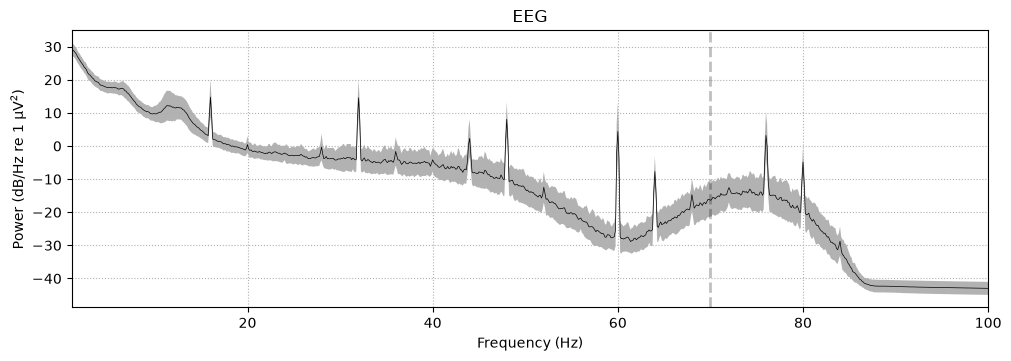

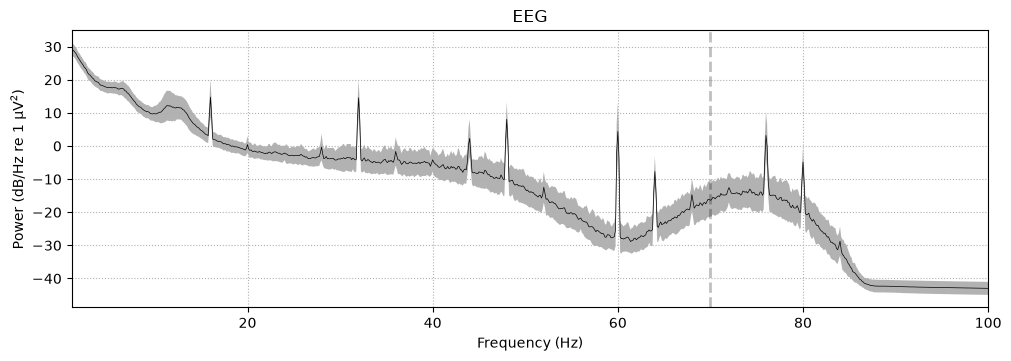

In [7]:
psd = raw_filtered.compute_psd(
    fmin=1,
    fmax=100,
    picks="eeg"
)

psd.plot(
    average=True,
    dB=True
)

In [8]:
# Defining the seizure interval from the CHB-MIT annotation
seizure_start = 2996
seizure_end = 3036

# Window configuration
window_size = 10       # seconds
step_size = 10         # seconds, no overlap for now

print("Seizure:", seizure_start, "to", seizure_end, "seconds")
print("Window size:", window_size, "seconds")
print("Step size:", step_size, "seconds")

Seizure: 2996 to 3036 seconds
Window size: 10 seconds
Step size: 10 seconds


In [9]:
# Labeling rule
MIN_SEIZURE_OVERLAP = 0.50

def get_window_label(window_start, window_end, seizure_start, seizure_end):
    """
    Assign a label to an EEG window based on its overlap
    with the annotated seizure interval.

    Returns:
        1 = seizure
        0 = non-seizure
        None = ambiguous / discard
    """
    
    overlap_start = max(window_start, seizure_start)
    overlap_end = min(window_end, seizure_end)

    overlap = max(0, overlap_end - overlap_start)
    window_duration = window_end - window_start

    overlap_ratio = overlap / window_duration

    if overlap_ratio >= MIN_SEIZURE_OVERLAP:
        return 1
    elif overlap_ratio == 0:
        return 0
    else:
        return None


# Test the rule
test_windows = [
    (2980, 2990),
    (2990, 3000),
    (3000, 3010),
    (3010, 3020),
    (3020, 3030),
    (3030, 3040),
    (3040, 3050),
]

for start, end in test_windows:
    label = get_window_label(
        start,
        end,
        seizure_start,
        seizure_end
    )

    print(f"{start:4d}-{end:4d} s  →  {label}")

2980-2990 s  →  0
2990-3000 s  →  None
3000-3010 s  →  1
3010-3020 s  →  1
3020-3030 s  →  1
3030-3040 s  →  1
3040-3050 s  →  0


In [10]:
# Generate 10-second windows from the recording

sfreq = raw_filtered.info["sfreq"]

window_samples = int(window_size * sfreq)
step_samples = int(step_size * sfreq)

windows = []
labels = []
window_times = []

n_samples = raw_filtered.n_times

for start_sample in range(0, n_samples - window_samples + 1, step_samples):

    end_sample = start_sample + window_samples

    start_time = start_sample / sfreq
    end_time = end_sample / sfreq

    label = get_window_label(
        start_time,
        end_time,
        seizure_start,
        seizure_end
    )

    # Keep only clearly labelled windows
    if label is not None:
        window = raw_filtered.get_data(
            start=start_sample,
            stop=end_sample
        )

        windows.append(window)
        labels.append(label)
        window_times.append((start_time, end_time))

windows = np.array(windows)
labels = np.array(labels)

print("Windows shape:", windows.shape)
print("Labels shape:", labels.shape)
print("Seizure windows:", np.sum(labels == 1))
print("Non-seizure windows:", np.sum(labels == 0))

Windows shape: (359, 23, 2560)
Labels shape: (359,)
Seizure windows: 4
Non-seizure windows: 355


In [11]:
print("One window shape:", windows[0].shape)
print("First window time:", window_times[0])
print("First window label:", labels[0])

print("\nLast window time:", window_times[-1])
print("Last window label:", labels[-1])

One window shape: (23, 2560)
First window time: (0.0, 10.0)
First window label: 0

Last window time: (3590.0, 3600.0)
Last window label: 0


In [12]:
seizure_indices = np.where(labels == 1)[0]

print("Seizure window indices:", seizure_indices)

for idx in seizure_indices:
    print(
        f"Window {idx}: "
        f"{window_times[idx][0]:.0f}-{window_times[idx][1]:.0f} s"
    )

Seizure window indices: [299 300 301 302]
Window 299: 3000-3010 s
Window 300: 3010-3020 s
Window 301: 3020-3030 s
Window 302: 3030-3040 s


In [13]:
import scipy
print(scipy.__version__)

1.17.1


In [14]:
import pandas as pd
from scipy.signal import welch

# Frequency bands
FREQUENCY_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 70),
}


def extract_channel_features(signal, sfreq):
    """
    Extract interpretable time- and frequency-domain
    features from one EEG channel/window.
    """

    features = {}

    # -------------------------
    # Time-domain features
    # -------------------------

    features["mean"] = np.mean(signal)

    features["std"] = np.std(signal)

    features["variance"] = np.var(signal)

    features["rms"] = np.sqrt(np.mean(signal ** 2))

    # Line length
    features["line_length"] = np.sum(np.abs(np.diff(signal)))

    # -------------------------
    # Frequency-domain features
    # -------------------------

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=min(len(signal), int(sfreq * 2))
    )

    total_power = np.trapezoid(power, frequencies)

    for band_name, (low, high) in FREQUENCY_BANDS.items():

        band_mask = (
            (frequencies >= low) &
            (frequencies < high)
        )

        band_power = np.trapezoid(
            power[band_mask],
            frequencies[band_mask]
        )

        # Relative power
        if total_power > 0:
            relative_power = band_power / total_power
        else:
            relative_power = 0

        features[f"{band_name}_relative_power"] = relative_power

    return features

In [15]:
sfreq = raw_filtered.info["sfreq"]

test_features = extract_channel_features(
    windows[0][0],
    sfreq
)

print("Number of features:", len(test_features))

for name, value in test_features.items():
    print(f"{name:25s}: {value:.6e}")

Number of features: 10
mean                     : 9.445993e-07
std                      : 2.660297e-05
variance                 : 7.077178e-10
rms                      : 2.661973e-05
line_length              : 1.088091e-02
delta_relative_power     : 4.552560e-01
theta_relative_power     : 1.586462e-01
alpha_relative_power     : 2.703360e-01
beta_relative_power      : 3.399464e-02
gamma_relative_power     : 1.087319e-02


In [16]:
all_features = []

sfreq = raw_filtered.info["sfreq"]

for window_idx, window in enumerate(windows):

    window_features = {
        "window_index": window_idx,
        "label": labels[window_idx]
    }

    for channel_idx, channel_name in enumerate(raw_filtered.ch_names):

        channel_features = extract_channel_features(
            window[channel_idx],
            sfreq
        )

        for feature_name, value in channel_features.items():

            column_name = f"{channel_name}_{feature_name}"

            window_features[column_name] = value

    all_features.append(window_features)


features_df = pd.DataFrame(all_features)

print("Feature matrix shape:", features_df.shape)
print("Number of windows:", len(features_df))
print("Number of feature columns:", len(features_df.columns) - 2)

Feature matrix shape: (359, 232)
Number of windows: 359
Number of feature columns: 230


In [17]:
print(features_df.head())
print("\nMissing values:", features_df.isna().sum().sum())
print("Infinite values:", np.isinf(features_df.select_dtypes(include=np.number)).sum().sum())

print("\nClass distribution:")
print(features_df["label"].value_counts())

print("\nClass percentages:")
print(features_df["label"].value_counts(normalize=True) * 100)

   window_index  label   FP1-F7_mean  FP1-F7_std  FP1-F7_variance  FP1-F7_rms  \
0             0      0  9.445993e-07    0.000027     7.077178e-10    0.000027   
1             1      0 -1.285704e-08    0.000030     9.166091e-10    0.000030   
2             2      0  4.427070e-08    0.000036     1.332046e-09    0.000036   
3             3      0 -2.897399e-07    0.000067     4.516309e-09    0.000067   
4             4      0 -2.469186e-07    0.000026     6.619004e-10    0.000026   

   FP1-F7_line_length  FP1-F7_delta_relative_power  \
0            0.010881                     0.455256   
1            0.011539                     0.428037   
2            0.012165                     0.525611   
3            0.025848                     0.642910   
4            0.008782                     0.418315   

   FP1-F7_theta_relative_power  FP1-F7_alpha_relative_power  ...  \
0                     0.158646                     0.270336  ...   
1                     0.150251                     0

In [18]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

features_path = results_dir / "features_chb01_03.csv"

features_df.to_csv(features_path, index=False)

print("Saved:", features_path)
print("File exists:", features_path.exists())
print("Size:", features_path.stat().st_size / 1024, "KB")

Saved: c:\Users\Soumya Bhardwaj\ML_PROJECT1\results\features_chb01_03.csv
File exists: True
Size: 1709.15625 KB


In [19]:
# Separate seizure and non-seizure windows
seizure_df = features_df[features_df["label"] == 1]
nonseizure_df = features_df[features_df["label"] == 0]

print("Seizure windows:", len(seizure_df))
print("Non-seizure windows:", len(nonseizure_df))


# Look at a few representative features from FP1-F7
features_to_check = [
    "FP1-F7_std",
    "FP1-F7_rms",
    "FP1-F7_line_length",
    "FP1-F7_delta_relative_power",
    "FP1-F7_theta_relative_power",
    "FP1-F7_alpha_relative_power",
    "FP1-F7_beta_relative_power",
    "FP1-F7_gamma_relative_power",
]

comparison = pd.DataFrame({
    "Feature": features_to_check,
    "Non-seizure mean": [
        nonseizure_df[f].mean() for f in features_to_check
    ],
    "Seizure mean": [
        seizure_df[f].mean() for f in features_to_check
    ],
})

comparison

Seizure windows: 4
Non-seizure windows: 355


,Feature,Non-seizure mean,Seizure mean
0,FP1-F7_std,0.000035,0.000114
1,FP1-F7_rms,0.000035,0.000114
2,FP1-F7_line_length,0.010571,0.045030
3,FP1-F7_delta_relative_power,0.591303,0.739208
4,FP1-F7_theta_relative_power,0.153551,0.098629
5,FP1-F7_alpha_relative_power,0.082148,0.007936
6,FP1-F7_beta_relative_power,0.044595,0.024327
7,FP1-F7_gamma_relative_power,0.022528,0.047473


In [20]:
print("raw_filtered exists:", "raw_filtered" in globals())
print("windows exists:", "windows" in globals())
print("labels exists:", "labels" in globals())

raw_filtered exists: True
windows exists: True
labels exists: True


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne

# Project root
PROJECT_ROOT = Path.cwd().parent

# EDF file
edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nSampling frequency:", raw.info["sfreq"], "Hz")
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Sampling frequency:

C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_32996\3282818937.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


 256.0 Hz
Channels: 23
Duration: 3599.99609375 seconds


In [22]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=70.0,
    picks="eeg",
    verbose=False
)

print("Band-pass filtering complete.")
print("Frequency range: 0.5–70 Hz")

Band-pass filtering complete.
Frequency range: 0.5–70 Hz


In [23]:
# Compare one non-seizure window with one seizure window

non_seizure_idx = 298
seizure_idx = 299

non_seizure_window = windows[non_seizure_idx]
seizure_window = windows[seizure_idx]

print("Non-seizure window:")
print("Index:", non_seizure_idx)
print("Time:", window_times[non_seizure_idx])
print("Label:", labels[non_seizure_idx])

print("\nSeizure window:")
print("Index:", seizure_idx)
print("Time:", window_times[seizure_idx])
print("Label:", labels[seizure_idx])

print("\nWindow shape:", non_seizure_window.shape)

Non-seizure window:
Index: 298
Time: (2980.0, 2990.0)
Label: 0

Seizure window:
Index: 299
Time: (3000.0, 3010.0)
Label: 1

Window shape: (23, 2560)


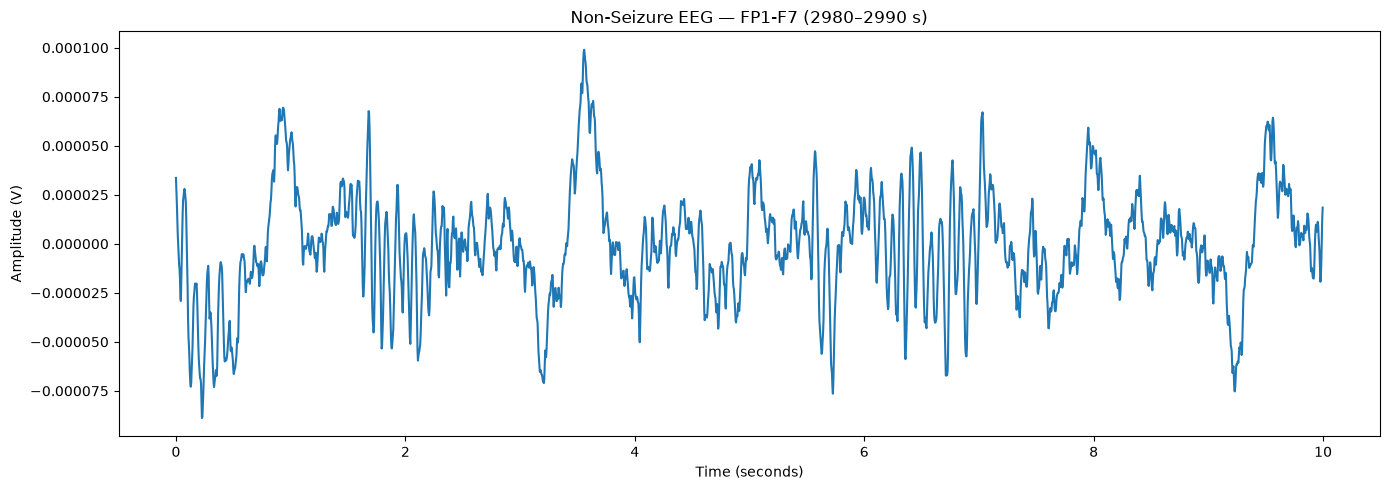

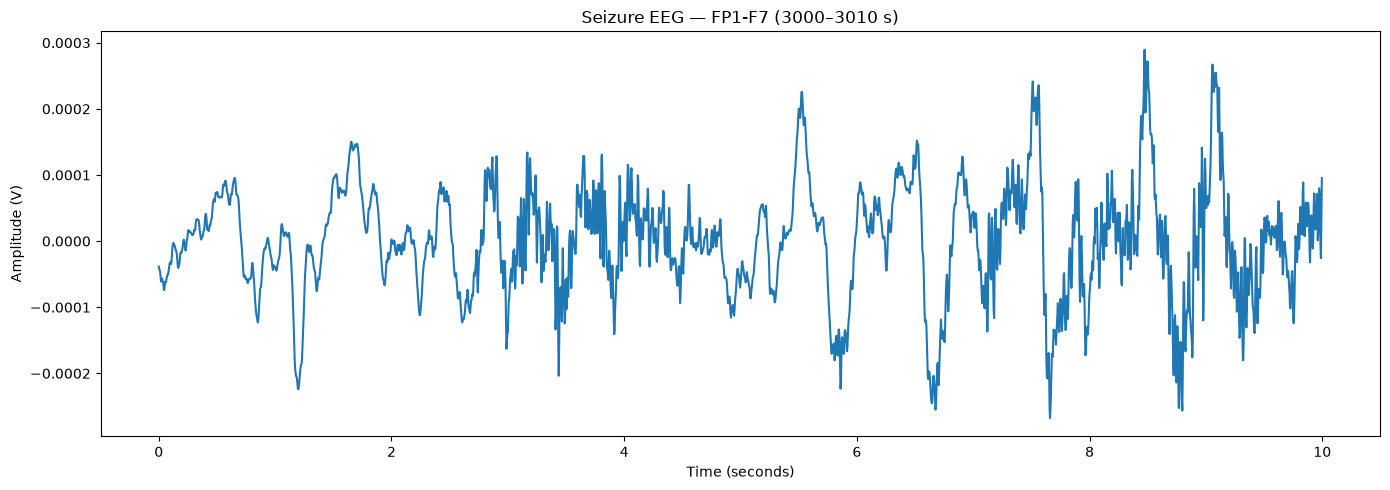

In [24]:
import matplotlib.pyplot as plt

channel_idx = raw_filtered.ch_names.index("FP1-F7")

non_seizure_signal = non_seizure_window[channel_idx]
seizure_signal = seizure_window[channel_idx]

time = np.arange(len(non_seizure_signal)) / raw_filtered.info["sfreq"]

plt.figure(figsize=(14, 5))

plt.plot(time, non_seizure_signal)

plt.title("Non-Seizure EEG — FP1-F7 (2980–2990 s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))

plt.plot(time, seizure_signal)

plt.title("Seizure EEG — FP1-F7 (3000–3010 s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.tight_layout()
plt.show()

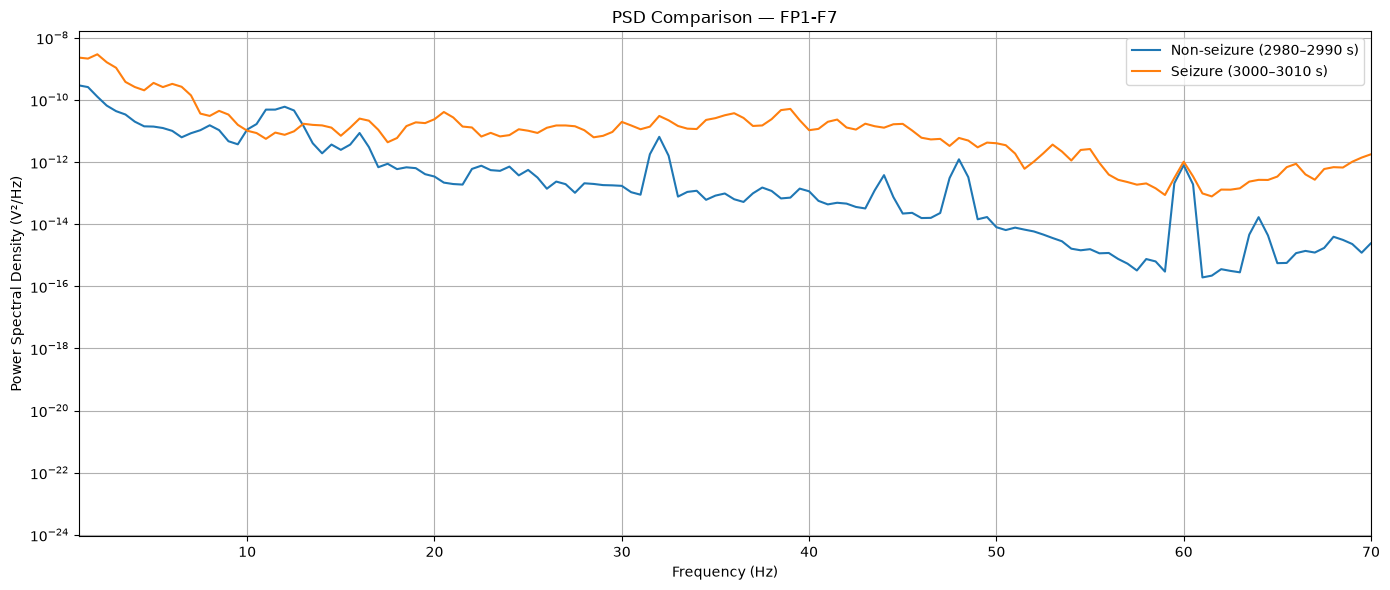

In [25]:
from scipy.signal import welch
import matplotlib.pyplot as plt

sfreq = raw_filtered.info["sfreq"]

# Calculate PSD for the same FP1-F7 windows
freq_non, psd_non = welch(
    non_seizure_signal,
    fs=sfreq,
    nperseg=sfreq * 2
)

freq_seiz, psd_seiz = welch(
    seizure_signal,
    fs=sfreq,
    nperseg=sfreq * 2
)

# Plot both on the same graph
plt.figure(figsize=(14, 6))

plt.semilogy(
    freq_non,
    psd_non,
    label="Non-seizure (2980–2990 s)"
)

plt.semilogy(
    freq_seiz,
    psd_seiz,
    label="Seizure (3000–3010 s)"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.title("PSD Comparison — FP1-F7")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

sfreq = raw_filtered.info["sfreq"]

# PSD for the same two FP1-F7 windows
freq_non, psd_non = welch(
    non_seizure_signal,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_seiz, psd_seiz = welch(
    seizure_signal,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

# Keep only frequencies between 1 and 70 Hz
mask_non = (freq_non >= 1) & (freq_non <= 70)
mask_seiz = (freq_seiz >= 1) & (freq_seiz <= 70)

# Log-transform
log_freq_non = np.log10(freq_non[mask_non])
log_psd_non = np.log10(psd_non[mask_non])

log_freq_seiz = np.log10(freq_seiz[mask_seiz])
log_psd_seiz = np.log10(psd_seiz[mask_seiz])

# Linear regression in log-log space
slope_non, intercept_non = np.polyfit(
    log_freq_non,
    log_psd_non,
    1
)

slope_seiz, intercept_seiz = np.polyfit(
    log_freq_seiz,
    log_psd_seiz,
    1
)

print("Spectral slope comparison")
print("--------------------------")
print(f"Non-seizure slope: {slope_non:.4f}")
print(f"Seizure slope:     {slope_seiz:.4f}")

Spectral slope comparison
--------------------------
Non-seizure slope: -3.4663
Seizure slope:     -2.0145


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------------------
# Noise configuration
# -----------------------------------------

sfreq = 256.0
duration = 10.0
n_samples = int(sfreq * duration)

rng = np.random.default_rng(42)

# Frequency range for comparison
fmin = 1
fmax = 70


# -----------------------------------------
# Generate white noise
# -----------------------------------------

white_noise = rng.normal(
    0,
    1,
    n_samples
)


# -----------------------------------------
# Generate colored noise using FFT
# -----------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate noise with approximately

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    # Start with random Fourier coefficients
    spectrum = (
        rng.normal(size=len(frequencies))
        + 1j * rng.normal(size=len(frequencies))
    )

    # Avoid division by zero at DC
    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC component
    spectrum[0] = 0

    # Convert back to time domain
    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize
    noise = (
        noise - np.mean(noise)
    ) / np.std(noise)

    return noise


pink_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=3,
    rng=rng
)


print("Noise generation complete.")
print("Sampling frequency:", sfreq, "Hz")
print("Duration:", duration, "seconds")
print("Samples:", n_samples)

Noise generation complete.
Sampling frequency: 256.0 Hz
Duration: 10.0 seconds
Samples: 2560


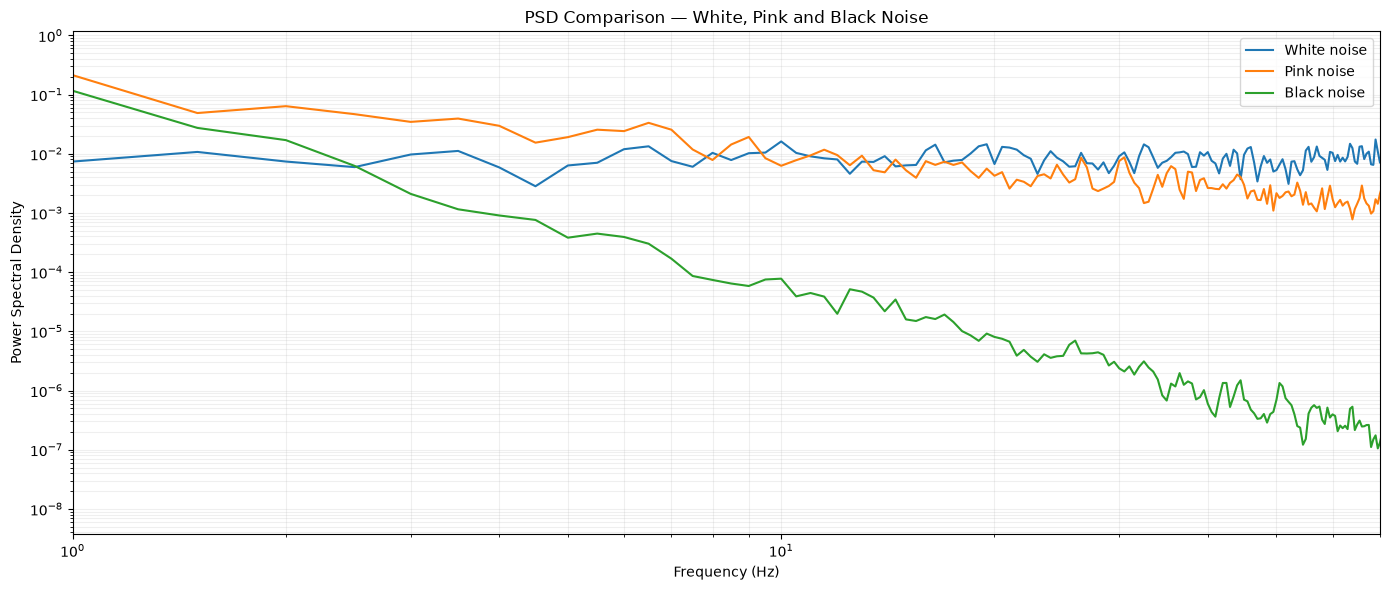

In [28]:
# -----------------------------------------
# Calculate PSD using Welch's method
# -----------------------------------------

freq_white, psd_white = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# -----------------------------------------
# Plot noise PSDs
# -----------------------------------------

plt.figure(figsize=(14, 6))

plt.loglog(
    freq_white,
    psd_white,
    label="White noise"
)

plt.loglog(
    freq_pink,
    psd_pink,
    label="Pink noise"
)

plt.loglog(
    freq_black,
    psd_black,
    label="Black noise"
)

plt.xlim(fmin, fmax)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.title(
    "PSD Comparison — White, Pink and Black Noise"
)

plt.legend()
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

In [29]:
from scipy.stats import linregress
import numpy as np

def calculate_spectral_slope(freq, psd, fmin=1, fmax=70):
    """
    Calculate spectral slope in log-log space.
    """

    mask = (
        (freq >= fmin) &
        (freq <= fmax) &
        (psd > 0)
    )

    log_freq = np.log10(freq[mask])
    log_psd = np.log10(psd[mask])

    slope, intercept, r_value, p_value, std_err = linregress(
        log_freq,
        log_psd
    )

    return slope


white_slope = calculate_spectral_slope(
    freq_white,
    psd_white
)

pink_slope = calculate_spectral_slope(
    freq_pink,
    psd_pink
)

black_slope = calculate_spectral_slope(
    freq_black,
    psd_black
)

print("Spectral slope comparison")
print("--------------------------")
print(f"White noise: {white_slope:.4f}")
print(f"Pink noise:  {pink_slope:.4f}")
print(f"Black noise: {black_slope:.4f}")

Spectral slope comparison
--------------------------
White noise: 0.0047
Pink noise:  -1.0343
Black noise: -3.0370


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Stochastic Resonance — canonical model
# -----------------------------------------

# Simulation parameters
dt = 0.01
duration = 500       # seconds
sfreq = 1 / dt

# Weak periodic input
signal_amplitude = 0.20
signal_frequency = 0.05   # Hz

# Bistable system parameters
a = 1.0
b = 1.0

# Noise intensities to test
noise_levels = np.linspace(0.01, 0.30, 20)

rng = np.random.default_rng(42)

n_samples = int(duration / dt)

time = np.arange(n_samples) * dt

print("Stochastic Resonance simulation")
print("--------------------------------")
print("Duration:", duration, "seconds")
print("Sampling frequency:", sfreq, "Hz")
print("Signal amplitude:", signal_amplitude)
print("Signal frequency:", signal_frequency, "Hz")
print("Number of noise levels:", len(noise_levels))

Stochastic Resonance simulation
--------------------------------
Duration: 500 seconds
Sampling frequency: 100.0 Hz
Signal amplitude: 0.2
Signal frequency: 0.05 Hz
Number of noise levels: 20


In [31]:
def simulate_bistable_system(
    noise_intensity,
    time,
    dt,
    signal_amplitude,
    signal_frequency,
    a=1.0,
    b=1.0,
    rng=None
):
    """
    Simulate an overdamped bistable nonlinear system:

        dx/dt = ax - bx^3 + A cos(2πft) + noise

    The system has two stable states.
    """

    if rng is None:
        rng = np.random.default_rng()

    x = np.zeros(len(time))

    # Start in one stable state
    x[0] = -1.0

    for i in range(len(time) - 1):

        periodic_signal = (
            signal_amplitude *
            np.cos(2 * np.pi * signal_frequency * time[i])
        )

        deterministic_part = (
            a * x[i]
            - b * x[i] ** 3
            + periodic_signal
        )

        stochastic_part = (
            np.sqrt(2 * noise_intensity * dt)
            * rng.normal()
        )

        x[i + 1] = (
            x[i]
            + deterministic_part * dt
            + stochastic_part
        )

    return x

In [32]:
responses = []

for noise in noise_levels:

    output = simulate_bistable_system(
        noise_intensity=noise,
        time=time,
        dt=dt,
        signal_amplitude=signal_amplitude,
        signal_frequency=signal_frequency,
        a=a,
        b=b,
        rng=rng
    )

    # Remove initial transient
    start = int(0.2 * len(output))

    output_segment = output[start:]
    time_segment = time[start:]

    # Measure response at the driving frequency
    reference = np.cos(
        2 * np.pi *
        signal_frequency *
        time_segment
    )

    response = abs(
        np.mean(
            output_segment * reference
        )
    )

    responses.append(response)


responses = np.array(responses)

print("SR simulation complete.")
print("Maximum response:", responses.max())
print(
    "Optimal noise intensity:",
    noise_levels[np.argmax(responses)]
)

SR simulation complete.
Maximum response: 0.16867700947429154
Optimal noise intensity: 0.2236842105263158


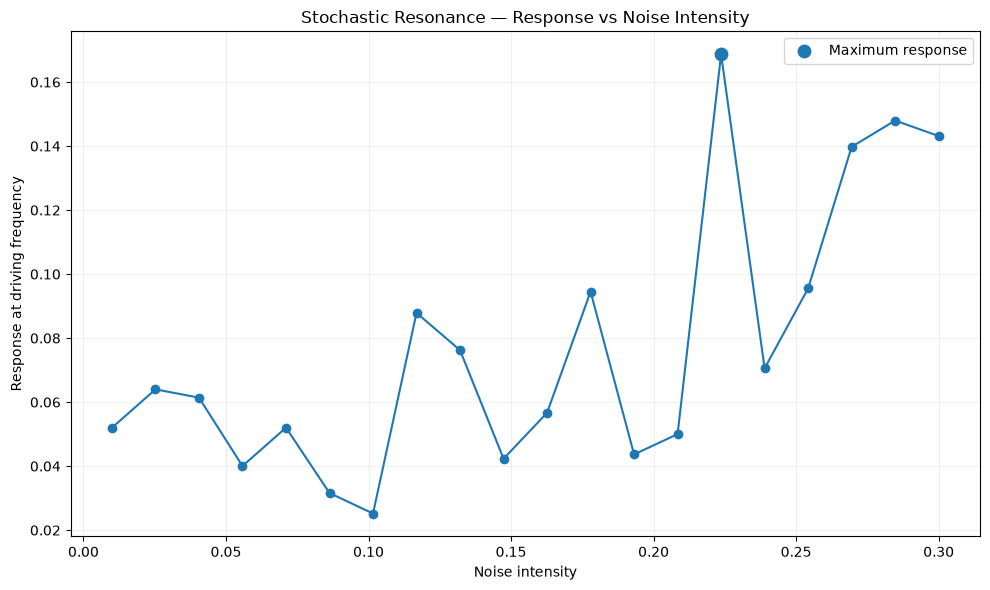

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    noise_levels,
    responses,
    marker="o"
)

optimal_index = np.argmax(responses)

plt.scatter(
    noise_levels[optimal_index],
    responses[optimal_index],
    s=80,
    label="Maximum response"
)

plt.xlabel("Noise intensity")
plt.ylabel("Response at driving frequency")

plt.title(
    "Stochastic Resonance — Response vs Noise Intensity"
)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---------------------------------------
# EEG-specific Stochastic Resonance
# FP1-F7 channel
# ---------------------------------------

channel_idx = 0   # FP1-F7

non_seizure_signal = windows[298][channel_idx]
seizure_signal = windows[299][channel_idx]

print("Non-seizure signal:", non_seizure_signal.shape)
print("Seizure signal:", seizure_signal.shape)
print("Sampling frequency:", sfreq)

Non-seizure signal: (2560,)
Seizure signal: (2560,)
Sampling frequency: 100.0


In [35]:
# Restore the actual EEG sampling frequency
sfreq = raw_filtered.info["sfreq"]

print("Actual EEG sampling frequency:", sfreq, "Hz")
print("Expected from window:", len(non_seizure_signal) / 10, "Hz")

Actual EEG sampling frequency: 256.0 Hz
Expected from window: 256.0 Hz


In [36]:
# ---------------------------------------
# EEG-specific Stochastic Resonance
# FP1-F7
# ---------------------------------------

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

def calculate_spectral_response(signal, sfreq):
    """
    Calculate the dominant-frequency response
    of an EEG signal.
    """
    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=sfreq * 2
    )

    # Focus on the EEG range
    mask = (frequencies >= 1) & (frequencies <= 70)

    frequencies = frequencies[mask]
    power = power[mask]

    # Dominant frequency
    dominant_idx = np.argmax(power)
    dominant_frequency = frequencies[dominant_idx]

    return dominant_frequency, power[dominant_idx]


# Find dominant frequencies of the two EEG windows

non_freq, non_response = calculate_spectral_response(
    non_seizure_signal,
    sfreq
)

seiz_freq, seiz_response = calculate_spectral_response(
    seizure_signal,
    sfreq
)

print("FP1-F7 EEG spectral response")
print("--------------------------------")
print(f"Non-seizure dominant frequency: {non_freq:.2f} Hz")
print(f"Non-seizure response: {non_response:.6e}")

print(f"\nSeizure dominant frequency: {seiz_freq:.2f} Hz")
print(f"Seizure response: {seiz_response:.6e}")

FP1-F7 EEG spectral response
--------------------------------
Non-seizure dominant frequency: 1.00 Hz
Non-seizure response: 2.926732e-10

Seizure dominant frequency: 2.00 Hz
Seizure response: 2.916559e-09


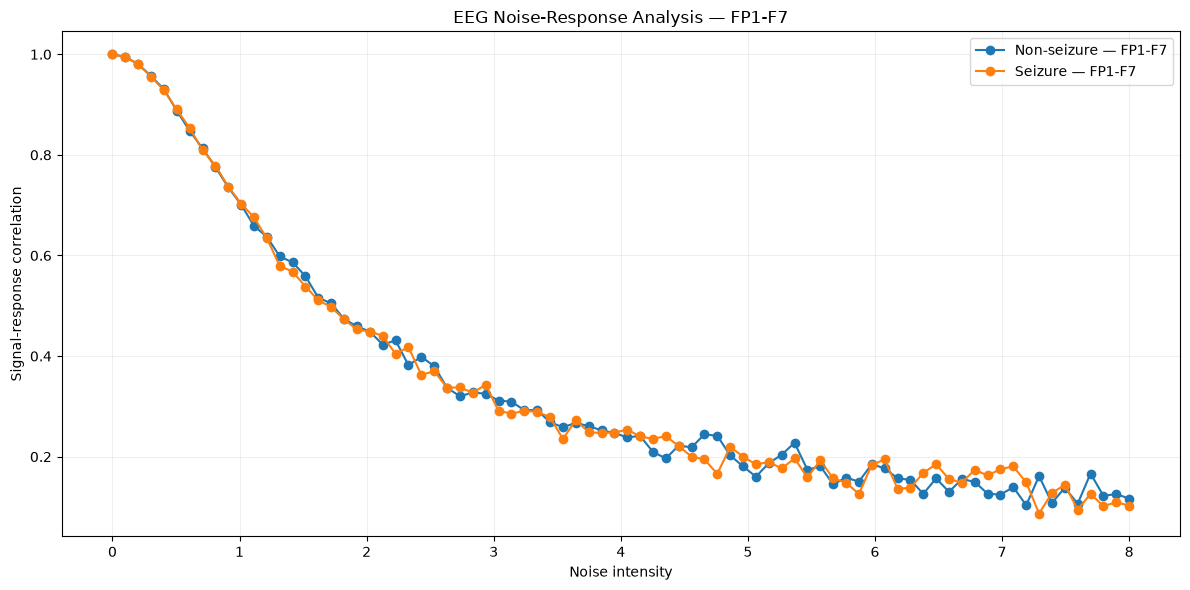

EEG noise-response results
---------------------------
Non-seizure maximum response: 1.0000
Non-seizure noise level: 0.00

Seizure maximum response: 1.0000
Seizure noise level: 0.00


In [37]:
# ==========================================
# EEG-specific Stochastic Resonance
# FP1-F7: seizure vs non-seizure
# ==========================================

from scipy.signal import correlate
import numpy as np
import matplotlib.pyplot as plt

# Make sure we are using the actual EEG sampling rate
sfreq = raw_filtered.info["sfreq"]

# The two windows we already selected
non_seizure_signal = windows[298][0]   # FP1-F7
seizure_signal = windows[299][0]       # FP1-F7

# Reproducible random generator
rng = np.random.default_rng(42)

# Normalize both signals so that noise intensity is comparable
non_seizure_norm = (
    non_seizure_signal - np.mean(non_seizure_signal)
) / np.std(non_seizure_signal)

seizure_norm = (
    seizure_signal - np.mean(seizure_signal)
) / np.std(seizure_signal)


# ------------------------------------------
# Noise levels
# ------------------------------------------

noise_levels = np.linspace(0.0, 8.0, 80)


# ------------------------------------------
# Response metric
# ------------------------------------------

def calculate_response(signal, noisy_signal):
    """
    Measure normalized zero-lag correlation
    between the original EEG and noisy EEG.
    """

    correlation = np.corrcoef(
        signal,
        noisy_signal
    )[0, 1]

    return abs(correlation)


# ------------------------------------------
# Run noise sweep
# ------------------------------------------

non_seizure_response = []
seizure_response = []

for noise_level in noise_levels:

    noise = rng.normal(
        0,
        noise_level,
        size=len(non_seizure_norm)
    )

    noisy_non_seizure = (
        non_seizure_norm + noise
    )

    noise = rng.normal(
        0,
        noise_level,
        size=len(seizure_norm)
    )

    noisy_seizure = (
        seizure_norm + noise
    )

    non_seizure_response.append(
        calculate_response(
            non_seizure_norm,
            noisy_non_seizure
        )
    )

    seizure_response.append(
        calculate_response(
            seizure_norm,
            noisy_seizure
        )
    )


non_seizure_response = np.array(
    non_seizure_response
)

seizure_response = np.array(
    seizure_response
)


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_seizure_response,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seizure_response,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Signal-response correlation")

plt.title(
    "EEG Noise-Response Analysis — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Report maxima
# ------------------------------------------

non_idx = np.argmax(non_seizure_response)
seiz_idx = np.argmax(seizure_response)

print("EEG noise-response results")
print("---------------------------")

print(
    f"Non-seizure maximum response: "
    f"{non_seizure_response[non_idx]:.4f}"
)

print(
    f"Non-seizure noise level: "
    f"{noise_levels[non_idx]:.2f}"
)

print()

print(
    f"Seizure maximum response: "
    f"{seizure_response[seiz_idx]:.4f}"
)

print(
    f"Seizure noise level: "
    f"{noise_levels[seiz_idx]:.2f}"
)

Non-seizure characteristic frequency: 1.10 Hz
Seizure characteristic frequency: 2.20 Hz


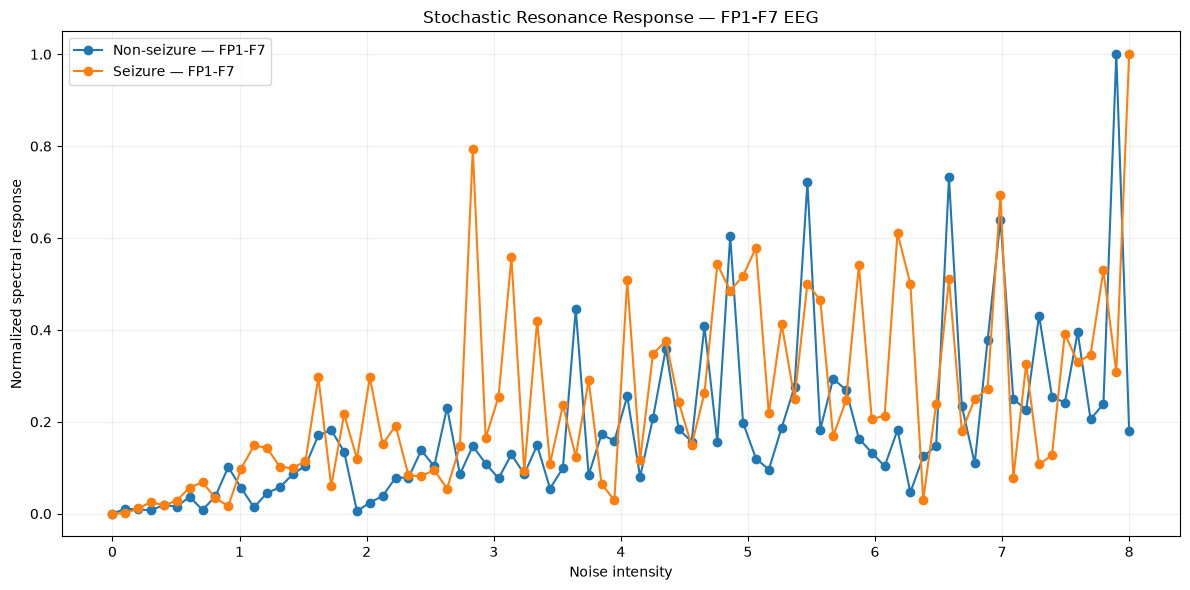


Stochastic Resonance Results
--------------------------------
Non-seizure optimal noise: 7.899
Non-seizure maximum response: 1.0000

Seizure optimal noise: 8.000
Seizure maximum response: 1.0000


In [38]:
# ==========================================
# Proper Stochastic Resonance Model
# FP1-F7 EEG
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------------
# Make sure the correct EEG sampling frequency is used
# ------------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# FP1-F7 windows
non_seizure_signal = windows[298][0]
seizure_signal = windows[299][0]

# ------------------------------------------------
# Normalize EEG signals
# ------------------------------------------------

def normalize_signal(signal):
    return (
        signal - np.mean(signal)
    ) / np.std(signal)


non_signal = normalize_signal(non_seizure_signal)
seiz_signal = normalize_signal(seizure_signal)


# ------------------------------------------------
# Find characteristic frequencies
# ------------------------------------------------

def dominant_frequency(signal, sfreq):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    power = power[mask]

    idx = np.argmax(power)

    return frequencies[idx]


non_freq = dominant_frequency(
    non_signal,
    sfreq
)

seiz_freq = dominant_frequency(
    seiz_signal,
    sfreq
)

print("Non-seizure characteristic frequency:",
      f"{non_freq:.2f} Hz")

print("Seizure characteristic frequency:",
      f"{seiz_freq:.2f} Hz")


# ------------------------------------------------
# Bistable stochastic-resonance simulation
# ------------------------------------------------

def bistable_sr(signal, sfreq, noise_intensity,
                input_scale=0.20):

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))

    # Start near one stable state
    x[0] = -1.0

    for i in range(1, len(signal)):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i-1] -
            x[i-1] ** 3
        )

        # EEG driving force
        driving_force = (
            input_scale *
            signal[i-1]
        )

        # Stochastic force
        stochastic_force = (
            np.sqrt(2 * noise_intensity * dt) *
            np.random.normal()
        )

        # Euler integration
        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force +
                driving_force
            )
            + stochastic_force
        )

        # Numerical safety
        if x[i] > 3:
            x[i] = 3

        elif x[i] < -3:
            x[i] = -3

    return x


# ------------------------------------------------
# Measure spectral response
# ------------------------------------------------

def spectral_response(signal, sfreq, target_frequency):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Look close to the characteristic frequency
    band = (
        (frequencies >= target_frequency - 0.2) &
        (frequencies <= target_frequency + 0.2)
    )

    if not np.any(band):
        return 0

    return np.max(power[band])


# ------------------------------------------------
# Noise sweep
# ------------------------------------------------

noise_levels = np.linspace(
    0.0,
    8.0,
    80
)

non_responses = []
seiz_responses = []


# Fixed random seed for reproducibility
np.random.seed(42)


for noise_level in noise_levels:

    # Non-seizure
    non_output = bistable_sr(
        non_signal,
        sfreq,
        noise_level
    )

    non_response = spectral_response(
        non_output,
        sfreq,
        non_freq
    )

    non_responses.append(
        non_response
    )


    # Seizure
    seiz_output = bistable_sr(
        seiz_signal,
        sfreq,
        noise_level
    )

    seiz_response = spectral_response(
        seiz_output,
        sfreq,
        seiz_freq
    )

    seiz_responses.append(
        seiz_response
    )


non_responses = np.array(non_responses)
seiz_responses = np.array(seiz_responses)


# ------------------------------------------------
# Normalize response curves
# ------------------------------------------------

if np.max(non_responses) > 0:
    non_responses_norm = (
        non_responses /
        np.max(non_responses)
    )
else:
    non_responses_norm = non_responses


if np.max(seiz_responses) > 0:
    seiz_responses_norm = (
        seiz_responses /
        np.max(seiz_responses)
    )
else:
    seiz_responses_norm = seiz_responses


# ------------------------------------------------
# Plt SR response curves
# ------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_responses_norm,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_responses_norm,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Normalized spectral response")

plt.title(
    "Stochastic Resonance Response — FP1-F7 EEG"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# Find optimal noise levels
# ------------------------------------------------

non_idx = np.argmax(non_responses)
seiz_idx = np.argmax(seiz_responses)

print("\nStochastic Resonance Results")
print("--------------------------------")

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_idx]:.3f}"
)

print(
    f"Non-seizure maximum response: "
    f"{non_responses_norm[non_idx]:.4f}"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_idx]:.3f}"
)

print(
    f"Seizure maximum response: "
    f"{seiz_responses_norm[seiz_idx]:.4f}"
)

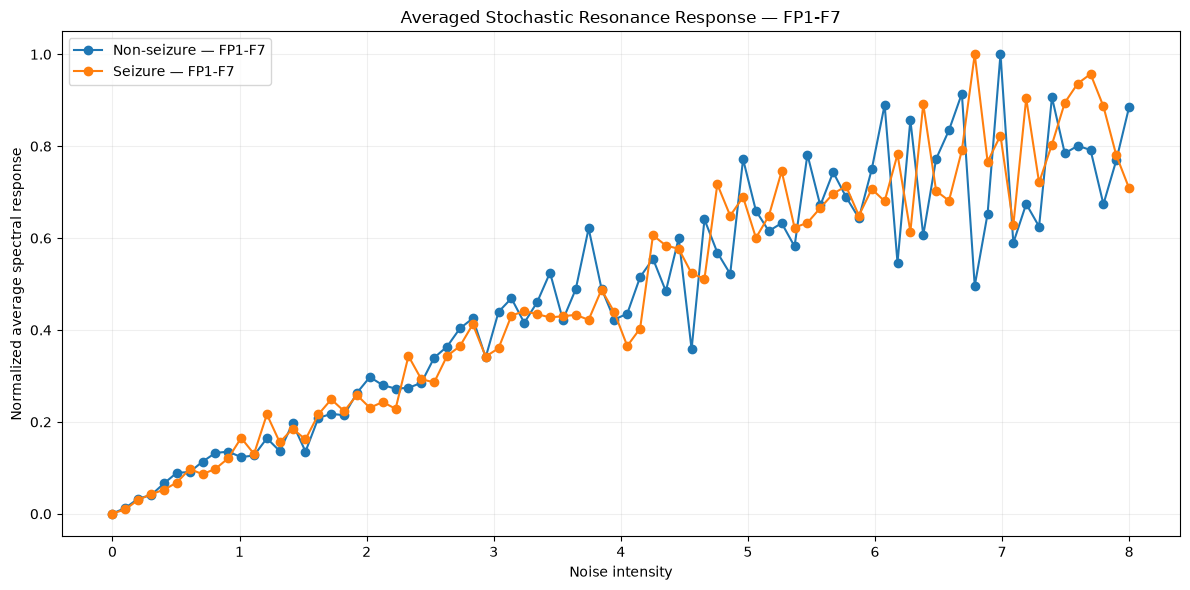

Final SR Analysis
Number of trials per noise level: 20

Non-seizure optimal noise: 6.987
Non-seizure maximum response: 1.0000

Seizure optimal noise: 6.785
Seizure maximum response: 1.0000


In [39]:
# ==========================================
# Final SR Analysis — Averaged Trials
# FP1-F7 EEG
# ==========================================

# Number of independent stochastic trials
N_TRIALS = 20

# Store averaged responses
non_responses_avg = []
seiz_responses_avg = []

# Use a reproducible random generator
rng = np.random.default_rng(42)


for noise_level in noise_levels:

    non_trial_responses = []
    seiz_trial_responses = []

    for trial in range(N_TRIALS):

        # -------------------------------
        # Non-seizure SR simulation
        # -------------------------------

        non_output = bistable_sr(
            non_signal,
            sfreq,
            noise_level
        )

        non_response = spectral_response(
            non_output,
            sfreq,
            non_freq
        )

        non_trial_responses.append(
            non_response
        )


        # -------------------------------
        # Seizure SR simulation
        # -------------------------------

        seiz_output = bistable_sr(
            seiz_signal,
            sfreq,
            noise_level
        )

        seiz_response = spectral_response(
            seiz_output,
            sfreq,
            seiz_freq
        )

        seiz_trial_responses.append(
            seiz_response
        )


    # Average across stochastic trials
    non_responses_avg.append(
        np.mean(non_trial_responses)
    )

    seiz_responses_avg.append(
        np.mean(seiz_trial_responses)
    )


non_responses_avg = np.array(non_responses_avg)
seiz_responses_avg = np.array(seiz_responses_avg)


# ------------------------------------------
# Normalize for comparison
# ------------------------------------------

non_responses_avg_norm = (
    non_responses_avg /
    np.max(non_responses_avg)
)

seiz_responses_avg_norm = (
    seiz_responses_avg /
    np.max(seiz_responses_avg)
)


# ------------------------------------------
# Find optimal noise levels
# ------------------------------------------

non_opt_idx = np.argmax(
    non_responses_avg
)

seiz_opt_idx = np.argmax(
    seiz_responses_avg
)


# ------------------------------------------
# Plot averaged SR curves
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_responses_avg_norm,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_responses_avg_norm,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")

plt.ylabel(
    "Normalized average spectral response"
)

plt.title(
    "Averaged Stochastic Resonance Response — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Final SR results
# ------------------------------------------

print("Final SR Analysis")
print("=================")

print(
    f"Number of trials per noise level: {N_TRIALS}"
)

print()

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_opt_idx]:.3f}"
)

print(
    f"Non-seizure maximum response: "
    f"{non_responses_avg_norm[non_opt_idx]:.4f}"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_opt_idx]:.3f}"
)

print(
    f"Seizure maximum response: "
    f"{seiz_responses_avg_norm[seiz_opt_idx]:.4f}"
)

In [40]:
# ==========================================
# Corrected SR spectral-SNR response
# FP1-F7 EEG
# ==========================================

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


def spectral_snr_response(signal, sfreq, target_frequency):
    """
    Calculate output spectral SNR around the
    characteristic frequency.

    Signal power is estimated near target_frequency.
    Noise floor is estimated from neighboring frequencies.
    """

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Signal band around characteristic frequency
    signal_band = (
        (frequencies >= target_frequency - 0.2) &
        (frequencies <= target_frequency + 0.2)
    )

    # Noise-floor region
    # Exclude the signal band itself
    noise_band = (
        (frequencies >= max(0.5, target_frequency - 2.0)) &
        (frequencies <= target_frequency + 2.0) &
        ~signal_band
    )

    if not np.any(signal_band) or not np.any(noise_band):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    snr_db = 10 * np.log10(
        signal_power / noise_floor
    )

    return snr_db

In [41]:
# Test the corrected SR response metric

test_non_output = bistable_sr(
    non_signal,
    sfreq,
    noise_intensity=1.0
)

test_seiz_output = bistable_sr(
    seiz_signal,
    sfreq,
    noise_intensity=1.0
)

non_test_snr = spectral_snr_response(
    test_non_output,
    sfreq,
    non_freq
)

seiz_test_snr = spectral_snr_response(
    test_seiz_output,
    sfreq,
    seiz_freq
)

print("Corrected SR response test")
print("--------------------------------")
print(f"Non-seizure SNR: {non_test_snr:.3f} dB")
print(f"Seizure SNR:     {seiz_test_snr:.3f} dB")

Corrected SR response test
--------------------------------
Non-seizure SNR: -1.703 dB
Seizure SNR:     -5.537 dB


In [42]:
# ==========================================
# SR Sweep using Spectral SNR
# FP1-F7 EEG
# ==========================================

N_TRIALS = 20

# Noise intensity range
noise_levels = np.linspace(
    0.0,
    8.0,
    41
)

non_snr_mean = []
seiz_snr_mean = []

non_snr_std = []
seiz_snr_std = []


# Reproducible random generator
rng = np.random.default_rng(42)


for noise_level in noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    for trial in range(N_TRIALS):

        # -------------------------
        # Non-seizure
        # -------------------------

        non_output = bistable_sr(
            non_signal,
            sfreq,
            noise_level
        )

        non_snr = spectral_snr_response(
            non_output,
            sfreq,
            non_freq
        )

        non_trial_snr.append(non_snr)


        # -------------------------
        # Seizure
        # -------------------------

        seiz_output = bistable_sr(
            seiz_signal,
            sfreq,
            noise_level
        )

        seiz_snr = spectral_snr_response(
            seiz_output,
            sfreq,
            seiz_freq
        )

        seiz_trial_snr.append(seiz_snr)


    # Average over trials
    non_snr_mean.append(
        np.nanmean(non_trial_snr)
    )

    seiz_snr_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    non_snr_std.append(
        np.nanstd(non_trial_snr)
    )

    seiz_snr_std.append(
        np.nanstd(seiz_trial_snr)
    )


non_snr_mean = np.array(non_snr_mean)
seiz_snr_mean = np.array(seiz_snr_mean)

non_snr_std = np.array(non_snr_std)
seiz_snr_std = np.array(seiz_snr_std)


# ==========================================
# Find actual maxima BEFORE normalization
# ==========================================

non_opt_idx = np.nanargmax(non_snr_mean)
seiz_opt_idx = np.nanargmax(seiz_snr_mean)


print("Stochastic Resonance — Spectral SNR")
print("------------------------------------------")

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_opt_idx]:.3f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{non_snr_mean[non_opt_idx]:.3f} dB"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_opt_idx]:.3f}"
)

print(
    f"Seizure maximum SNR: "
    f"{seiz_snr_mean[seiz_opt_idx]:.3f} dB"
)

Stochastic Resonance — Spectral SNR
------------------------------------------
Non-seizure optimal noise: 0.000
Non-seizure maximum SNR: 5.666 dB

Seizure optimal noise: 0.000
Seizure maximum SNR: 0.433 dB


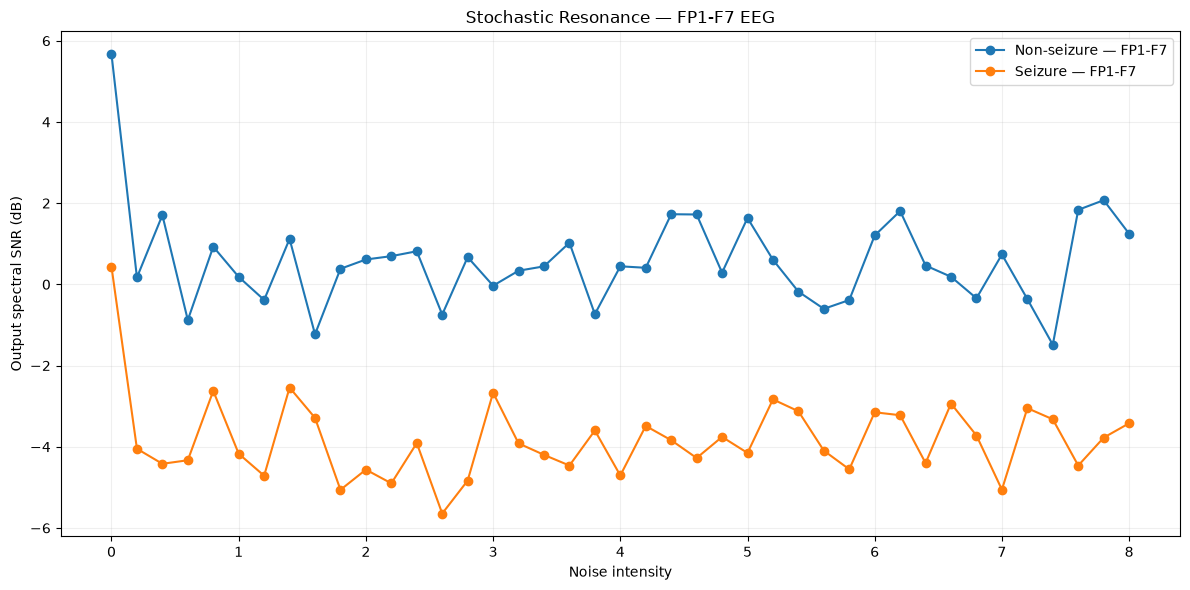

In [43]:
# ==========================================
# SR Spectral-SNR Curves
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_snr_mean,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_snr_mean,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Output spectral SNR (dB)")

plt.title(
    "Stochastic Resonance — FP1-F7 EEG"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [44]:
# ==========================================
# SR RESTART — Extract characteristic EEG component
# FP1-F7
# ==========================================

from scipy.signal import butter, filtfilt, welch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Basic parameters
# ------------------------------------------------

sfreq = raw_filtered.info["sfreq"]

non_seizure_signal = windows[298][0]
seizure_signal = windows[299][0]

print("Sampling frequency:", sfreq)
print("Non-seizure signal:", non_seizure_signal.shape)
print("Seizure signal:", seizure_signal.shape)


# ------------------------------------------------
# Characteristic frequencies found previously
# ------------------------------------------------

non_freq = 1.10
seiz_freq = 2.20

print()
print("Non-seizure characteristic frequency:",
      non_freq, "Hz")

print("Seizure characteristic frequency:",
      seiz_freq, "Hz")


# ------------------------------------------------
# Band-pass around characteristic frequency
# ------------------------------------------------

def extract_characteristic_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    low = max(0.2, center_frequency - bandwidth)
    high = min(
        sfreq / 2 - 1,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return component


non_component = extract_characteristic_component(
    non_seizure_signal,
    sfreq,
    non_freq
)

seiz_component = extract_characteristic_component(
    seizure_signal,
    sfreq,
    seiz_freq
)


# ------------------------------------------------
# Normalize characteristic components
# ------------------------------------------------

non_component = (
    non_component -
    np.mean(non_component)
) / np.std(non_component)

seiz_component = (
    seiz_component -
    np.mean(seiz_component)
) / np.std(seiz_component)


print()
print("Characteristic components extracted.")
print("Non-seizure std:",
      np.std(non_component))

print("Seizure std:",
      np.std(seiz_component))

Sampling frequency: 256.0
Non-seizure signal: (2560,)
Seizure signal: (2560,)

Non-seizure characteristic frequency: 1.1 Hz
Seizure characteristic frequency: 2.2 Hz

Characteristic components extracted.
Non-seizure std: 1.0
Seizure std: 1.0


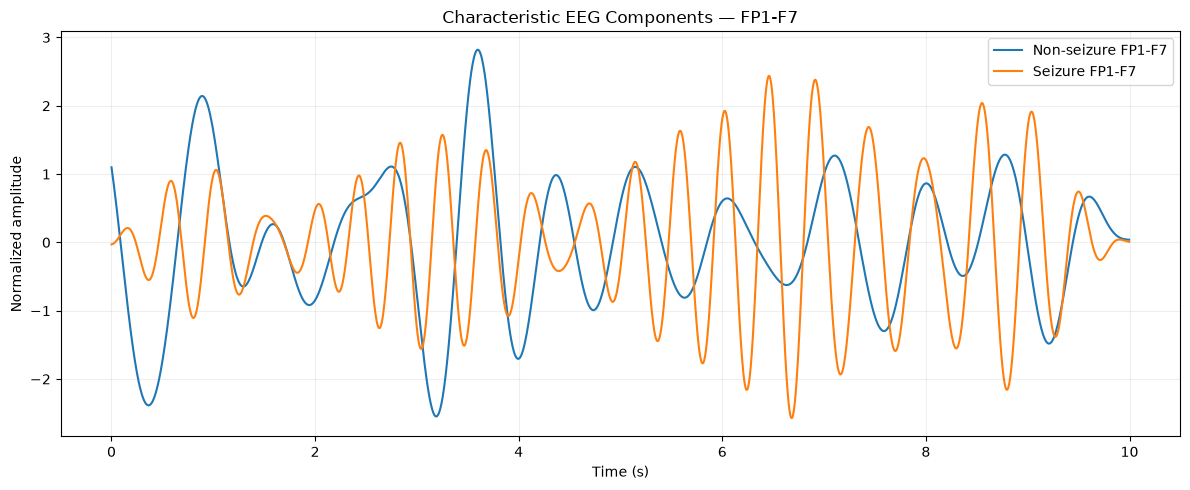

In [45]:
# ==========================================
# Visual verification
# ==========================================

time = np.arange(len(non_component)) / sfreq

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    non_component,
    label="Non-seizure FP1-F7"
)

plt.plot(
    time,
    seiz_component,
    label="Seizure FP1-F7"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")

plt.title(
    "Characteristic EEG Components — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [46]:
# ==========================================
# Canonical Bistable Stochastic Resonance
# ==========================================

def bistable_sr_component(
    input_signal,
    sfreq,
    noise_intensity,
    input_scale=0.20
):

    dt = 1.0 / sfreq

    x = np.zeros(len(input_signal))

    # Start in one stable well
    x[0] = -1.0

    for i in range(1, len(input_signal)):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i-1] -
            x[i-1] ** 3
        )

        # Weak EEG driving signal
        driving_force = (
            input_scale *
            input_signal[i-1]
        )

        # Gaussian white noise
        stochastic_force = (
            np.sqrt(
                2 *
                noise_intensity *
                dt
            )
            *
            np.random.normal()
        )

        # Euler integration
        x[i] = (
            x[i-1]
            +
            dt *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )

        # Numerical safety
        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x

In [47]:
# ==========================================
# Output Spectral SNR
# ==========================================

def calculate_snr(
    output,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        output,
        fs=sfreq,
        nperseg=len(output)
    )

    # Signal band
    signal_band = (
        (frequencies >= target_frequency - 0.15) &
        (frequencies <= target_frequency + 0.15)
    )

    # Noise floor:
    # nearby frequencies excluding signal band
    noise_band = (
        (frequencies >= max(
            0.2,
            target_frequency - 1.0
        ))
        &
        (frequencies <= target_frequency + 1.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or
        not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_power = np.mean(
        power[noise_band]
    )

    if noise_power <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power /
        noise_power
    )

In [48]:
# ==========================================
# SR Sanity Test
# ==========================================

np.random.seed(42)

test_noise = 0.10

non_test_output = bistable_sr_component(
    non_component,
    sfreq,
    test_noise
)

seiz_test_output = bistable_sr_component(
    seiz_component,
    sfreq,
    test_noise
)

non_test_snr = calculate_snr(
    non_test_output,
    sfreq,
    non_freq
)

seiz_test_snr = calculate_snr(
    seiz_test_output,
    sfreq,
    seiz_freq
)

print("SR Sanity Test")
print("--------------------------------")

print(
    f"Noise intensity: {test_noise}"
)

print(
    f"Non-seizure SNR: "
    f"{non_test_snr:.3f} dB"
)

print(
    f"Seizure SNR: "
    f"{seiz_test_snr:.3f} dB"
)

SR Sanity Test
--------------------------------
Noise intensity: 0.1
Non-seizure SNR: -7.461 dB
Seizure SNR: -6.390 dB


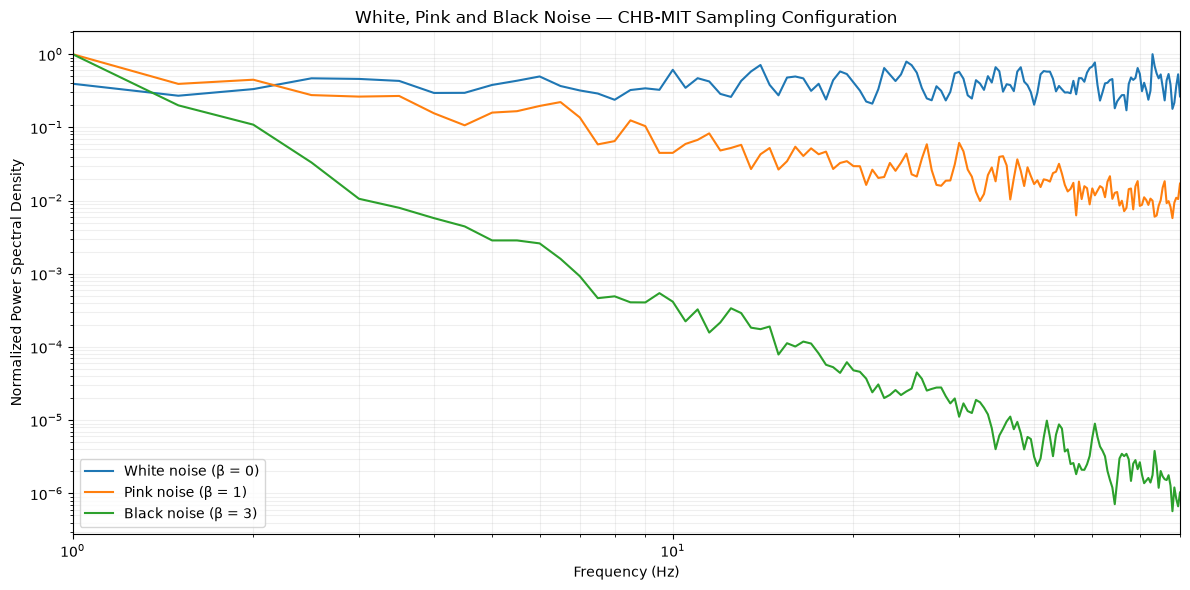

In [49]:
# ==========================================
# White / Pink / Black Noise
# Actual CHB-MIT sampling configuration
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Use the actual CHB-MIT sampling frequency
sfreq = raw_filtered.info["sfreq"]

# Use the same 10-second duration as our actual EEG windows
n_samples = len(non_seizure_signal)

rng = np.random.default_rng(42)

# Frequency range
fmin = 1
fmax = 70


# ------------------------------------------
# Generate colored noise
# ------------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate colored noise with approximately

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    spectrum = (
        rng.normal(size=len(frequencies))
        +
        1j * rng.normal(size=len(frequencies))
    )

    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC
    spectrum[0] = 0

    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize
    noise = (
        noise - np.mean(noise)
    ) / np.std(noise)

    return noise


white_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=0,
    rng=rng
)

pink_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=3,
    rng=rng
)


# ------------------------------------------
# PSD
# ------------------------------------------

freq_white, psd_white = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Frequency range
# ------------------------------------------

mask_white = (
    (freq_white >= fmin) &
    (freq_white <= fmax)
)

mask_pink = (
    (freq_pink >= fmin) &
    (freq_pink <= fmax)
)

mask_black = (
    (freq_black >= fmin) &
    (freq_black <= fmax)
)


# ------------------------------------------
# Normalize each PSD
# ------------------------------------------

psd_white_norm = (
    psd_white[mask_white] /
    np.max(psd_white[mask_white])
)

psd_pink_norm = (
    psd_pink[mask_pink] /
    np.max(psd_pink[mask_pink])
)

psd_black_norm = (
    psd_black[mask_black] /
    np.max(psd_black[mask_black])
)


# ------------------------------------------
# FINAL 3-LINE GRAPH
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.loglog(
    freq_white[mask_white],
    psd_white_norm,
    label="White noise (β = 0)"
)

plt.loglog(
    freq_pink[mask_pink],
    psd_pink_norm,
    label="Pink noise (β = 1)"
)

plt.loglog(
    freq_black[mask_black],
    psd_black_norm,
    label="Black noise (β = 3)"
)

plt.xlim(fmin, fmax)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectral Density")

plt.title(
    "White, Pink and Black Noise — CHB-MIT Sampling Configuration"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [50]:
# ==========================================
# Verify White / Pink / Black Spectral Slopes
# ==========================================

from scipy.stats import linregress


def calculate_spectral_slope(
    frequencies,
    power
):

    mask = (
        (frequencies >= 1) &
        (frequencies <= 70) &
        (power > 0)
    )

    log_frequency = np.log10(
        frequencies[mask]
    )

    log_power = np.log10(
        power[mask]
    )

    slope, intercept, r_value, p_value, std_err = (
        linregress(
            log_frequency,
            log_power
        )
    )

    return slope, r_value ** 2


white_slope, white_r2 = calculate_spectral_slope(
    freq_white,
    psd_white
)

pink_slope, pink_r2 = calculate_spectral_slope(
    freq_pink,
    psd_pink
)

black_slope, black_r2 = calculate_spectral_slope(
    freq_black,
    psd_black
)


print("White / Pink / Black Verification")
print("==================================")

print(
    f"White noise → slope = {white_slope:.4f}, "
    f"R² = {white_r2:.4f}"
)

print(
    f"Pink noise  → slope = {pink_slope:.4f}, "
    f"R² = {pink_r2:.4f}"
)

print(
    f"Black noise → slope = {black_slope:.4f}, "
    f"R² = {black_r2:.4f}"
)

White / Pink / Black Verification
White noise → slope = 0.0137, R² = 0.0012
Pink noise  → slope = -1.0258, R² = 0.8659
Black noise → slope = -3.0480, R² = 0.9782


In [51]:
# ==========================================
# ACTUAL CHB-MIT EEG
# White / Pink / Black Noise Injection
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------
# Actual CHB-MIT EEG
# ------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# Actual seizure EEG
actual_eeg = windows[299][0]   # FP1-F7, 3000–3010 s

print("Actual CHB-MIT EEG")
print("------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Time: 3000–3010 s")
print("Sampling frequency:", sfreq, "Hz")
print("Samples:", len(actual_eeg))


# ------------------------------------------
# Colored-noise generator
# ------------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate colored noise with:

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    spectrum = (
        rng.normal(size=len(frequencies))
        +
        1j * rng.normal(size=len(frequencies))
    )

    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC
    spectrum[0] = 0

    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize to zero mean and unit RMS
    noise = noise - np.mean(noise)
    noise = noise / np.std(noise)

    return noise


# ------------------------------------------
# Generate noise
# ------------------------------------------

rng = np.random.default_rng(42)

white_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=0,
    rng=rng
)

pink_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=3,
    rng=rng
)


# ------------------------------------------
# Add noise to ACTUAL EEG
# ------------------------------------------

noise_ratio = 0.30

eeg_rms = np.std(actual_eeg)

white_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * white_noise
)

pink_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * pink_noise
)

black_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * black_noise
)


print()
print("Noise injection complete.")
print("Noise RMS / EEG RMS:", noise_ratio)

Actual CHB-MIT EEG
------------------
File: chb01_03.edf
Channel: FP1-F7
Time: 3000–3010 s
Sampling frequency: 256.0 Hz
Samples: 2560

Noise injection complete.
Noise RMS / EEG RMS: 0.3


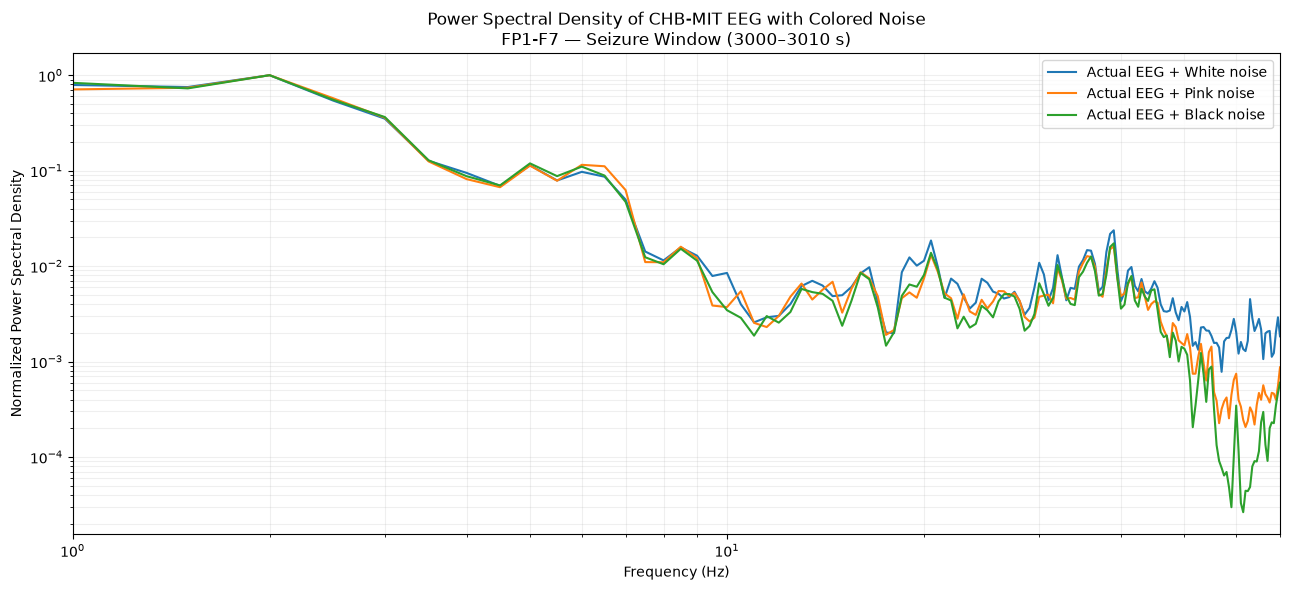

In [52]:
# ==========================================
# PSD — ACTUAL CHB-MIT EEG + Colored Noise
# ==========================================

# Calculate PSDs

freq_white, psd_white = welch(
    white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Keep 1–70 Hz
# ------------------------------------------

mask_white = (
    (freq_white >= 1) &
    (freq_white <= 70)
)

mask_pink = (
    (freq_pink >= 1) &
    (freq_pink <= 70)
)

mask_black = (
    (freq_black >= 1) &
    (freq_black <= 70)
)


# ------------------------------------------
# Normalize for visual comparison
# ------------------------------------------

psd_white_norm = (
    psd_white[mask_white] /
    np.max(psd_white[mask_white])
)

psd_pink_norm = (
    psd_pink[mask_pink] /
    np.max(psd_pink[mask_pink])
)

psd_black_norm = (
    psd_black[mask_black] /
    np.max(psd_black[mask_black])
)


# ------------------------------------------
# FINAL THREE-LINE GRAPH
# ------------------------------------------

plt.figure(figsize=(13, 6))

plt.loglog(
    freq_white[mask_white],
    psd_white_norm,
    label="Actual EEG + White noise"
)

plt.loglog(
    freq_pink[mask_pink],
    psd_pink_norm,
    label="Actual EEG + Pink noise"
)

plt.loglog(
    freq_black[mask_black],
    psd_black_norm,
    label="Actual EEG + Black noise"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectral Density")

plt.title(
    "Power Spectral Density of CHB-MIT EEG with Colored Noise"
    "\nFP1-F7 — Seizure Window (3000–3010 s)"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# ==========================================
# Verify Injected Noise Characteristics
# ==========================================

def spectral_slope(freq, psd):

    mask = (
        (freq >= 1) &
        (freq <= 70) &
        (psd > 0)
    )

    x = np.log10(freq[mask])
    y = np.log10(psd[mask])

    slope = np.polyfit(x, y, 1)[0]

    return slope


# PSD of noise components themselves

f_w, p_w = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_p, p_p = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_b, p_b = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


print("Injected Noise Verification")
print("============================")

print(
    f"White noise slope: "
    f"{spectral_slope(f_w, p_w):.4f}"
)

print(
    f"Pink noise slope:  "
    f"{spectral_slope(f_p, p_p):.4f}"
)

print(
    f"Black noise slope: "
    f"{spectral_slope(f_b, p_b):.4f}"
)

print()
print("Expected:")
print("White ≈  0")
print("Pink  ≈ -1")
print("Black ≈ -3")

Injected Noise Verification
White noise slope: 0.0137
Pink noise slope:  -1.0258
Black noise slope: -3.0480

Expected:
White ≈  0
Pink  ≈ -1
Black ≈ -3


In [54]:
# ==========================================
# ACTUAL CHB-MIT EEG
# NON-SEIZURE
# White / Pink / Black Noise Injection
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------
# Actual CHB-MIT EEG
# ------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# NON-SEIZURE EEG
actual_eeg = windows[298][0]   # FP1-F7, 2980–2990 s

print("Actual CHB-MIT EEG")
print("------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("State: NON-SEIZURE")
print("Time: 2980–2990 s")
print("Sampling frequency:", sfreq, "Hz")
print("Samples:", len(actual_eeg))


# ------------------------------------------
# Colored-noise generator
# ------------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate colored noise with:

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    spectrum = (
        rng.normal(size=len(frequencies))
        +
        1j * rng.normal(size=len(frequencies))
    )

    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    spectrum[0] = 0

    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    noise = noise - np.mean(noise)
    noise = noise / np.std(noise)

    return noise


# ------------------------------------------
# Generate noise
# ------------------------------------------

rng = np.random.default_rng(42)

white_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=0,
    rng=rng
)

pink_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=3,
    rng=rng
)


# ------------------------------------------
# Add noise to ACTUAL EEG
# ------------------------------------------

noise_ratio = 0.30

eeg_rms = np.std(actual_eeg)

white_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * white_noise
)

pink_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * pink_noise
)

black_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * black_noise
)


print()
print("Noise injection complete.")
print("Noise RMS / EEG RMS:", noise_ratio)

Actual CHB-MIT EEG
------------------
File: chb01_03.edf
Channel: FP1-F7
State: NON-SEIZURE
Time: 2980–2990 s
Sampling frequency: 256.0 Hz
Samples: 2560

Noise injection complete.
Noise RMS / EEG RMS: 0.3


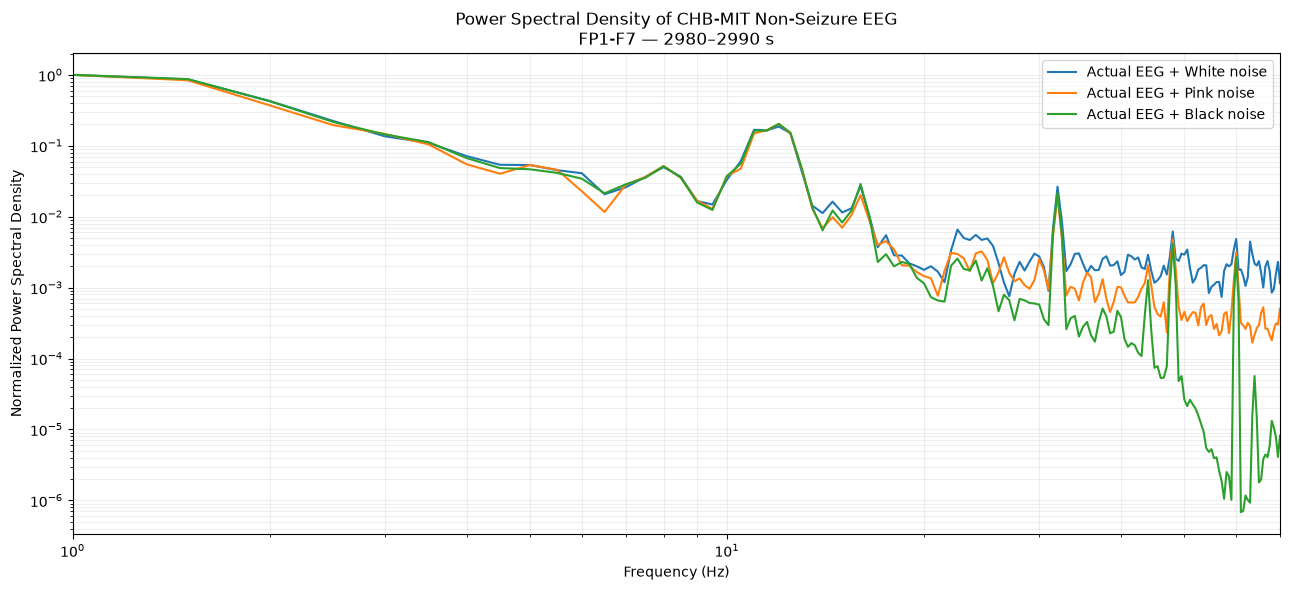

In [55]:
# ==========================================
# PSD — ACTUAL CHB-MIT NON-SEIZURE EEG
# ==========================================

freq_white, psd_white = welch(
    white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# 1–70 Hz
# ------------------------------------------

mask_white = (
    (freq_white >= 1) &
    (freq_white <= 70)
)

mask_pink = (
    (freq_pink >= 1) &
    (freq_pink <= 70)
)

mask_black = (
    (freq_black >= 1) &
    (freq_black <= 70)
)


# ------------------------------------------
# Normalize
# ------------------------------------------

psd_white_norm = (
    psd_white[mask_white] /
    np.max(psd_white[mask_white])
)

psd_pink_norm = (
    psd_pink[mask_pink] /
    np.max(psd_pink[mask_pink])
)

psd_black_norm = (
    psd_black[mask_black] /
    np.max(psd_black[mask_black])
)


# ------------------------------------------
# FINAL THREE-LINE GRAPH
# ------------------------------------------

plt.figure(figsize=(13, 6))

plt.loglog(
    freq_white[mask_white],
    psd_white_norm,
    label="Actual EEG + White noise"
)

plt.loglog(
    freq_pink[mask_pink],
    psd_pink_norm,
    label="Actual EEG + Pink noise"
)

plt.loglog(
    freq_black[mask_black],
    psd_black_norm,
    label="Actual EEG + Black noise"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectral Density")

plt.title(
    "Power Spectral Density of CHB-MIT Non-Seizure EEG"
    "\nFP1-F7 — 2980–2990 s"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [56]:
# ==========================================
# SAVE NON-SEIZURE COLORED-NOISE SIGNALS
# ==========================================

# Use the actual non-seizure CHB-MIT EEG
nonseizure_eeg = windows[298][0]

# Same noise strength used for seizure analysis
noise_ratio = 0.30

# EEG RMS
nonseizure_eeg_rms = np.std(nonseizure_eeg)

# Generate a fresh, reproducible set of noise signals
nonseizure_rng = np.random.default_rng(42)

nonseizure_white_noise = generate_colored_noise(
    len(nonseizure_eeg),
    sfreq,
    beta=0,
    rng=nonseizure_rng
)

nonseizure_pink_noise = generate_colored_noise(
    len(nonseizure_eeg),
    sfreq,
    beta=1,
    rng=nonseizure_rng
)

nonseizure_black_noise = generate_colored_noise(
    len(nonseizure_eeg),
    sfreq,
    beta=3,
    rng=nonseizure_rng
)


# Add noise to actual non-seizure EEG

nonseizure_white_noisy = (
    nonseizure_eeg
    + noise_ratio * nonseizure_eeg_rms * nonseizure_white_noise
)

nonseizure_pink_noisy = (
    nonseizure_eeg
    + noise_ratio * nonseizure_eeg_rms * nonseizure_pink_noise
)

nonseizure_black_noisy = (
    nonseizure_eeg
    + noise_ratio * nonseizure_eeg_rms * nonseizure_black_noise
)


print("Non-seizure signals saved")
print("------------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Window: 2980–2990 s")
print("Samples:", len(nonseizure_eeg))
print("Noise RMS / EEG RMS:", noise_ratio)

Non-seizure signals saved
------------------------
File: chb01_03.edf
Channel: FP1-F7
Window: 2980–2990 s
Samples: 2560
Noise RMS / EEG RMS: 0.3


In [57]:
# ==========================================
# PRESERVE SEIZURE COLORED-NOISE SIGNALS
# ==========================================

# Actual CHB-MIT seizure EEG
seizure_eeg = windows[299][0]

# Same parameters used in the original seizure experiment
seizure_noise_ratio = 0.30
seizure_eeg_rms = np.std(seizure_eeg)

# Recreate the exact same noise sequence
seizure_rng = np.random.default_rng(42)

seizure_white_noise = generate_colored_noise(
    len(seizure_eeg),
    sfreq,
    beta=0,
    rng=seizure_rng
)

seizure_pink_noise = generate_colored_noise(
    len(seizure_eeg),
    sfreq,
    beta=1,
    rng=seizure_rng
)

seizure_black_noise = generate_colored_noise(
    len(seizure_eeg),
    sfreq,
    beta=3,
    rng=seizure_rng
)


# Add noise to actual seizure EEG

seizure_white_noisy = (
    seizure_eeg
    + seizure_noise_ratio * seizure_eeg_rms * seizure_white_noise
)

seizure_pink_noisy = (
    seizure_eeg
    + seizure_noise_ratio * seizure_eeg_rms * seizure_pink_noise
)

seizure_black_noisy = (
    seizure_eeg
    + seizure_noise_ratio * seizure_eeg_rms * seizure_black_noise
)


print("Seizure signals preserved")
print("-------------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Window: 3000–3010 s")
print("Samples:", len(seizure_eeg))
print("Noise RMS / EEG RMS:", seizure_noise_ratio)

Seizure signals preserved
-------------------------
File: chb01_03.edf
Channel: FP1-F7
Window: 3000–3010 s
Samples: 2560
Noise RMS / EEG RMS: 0.3


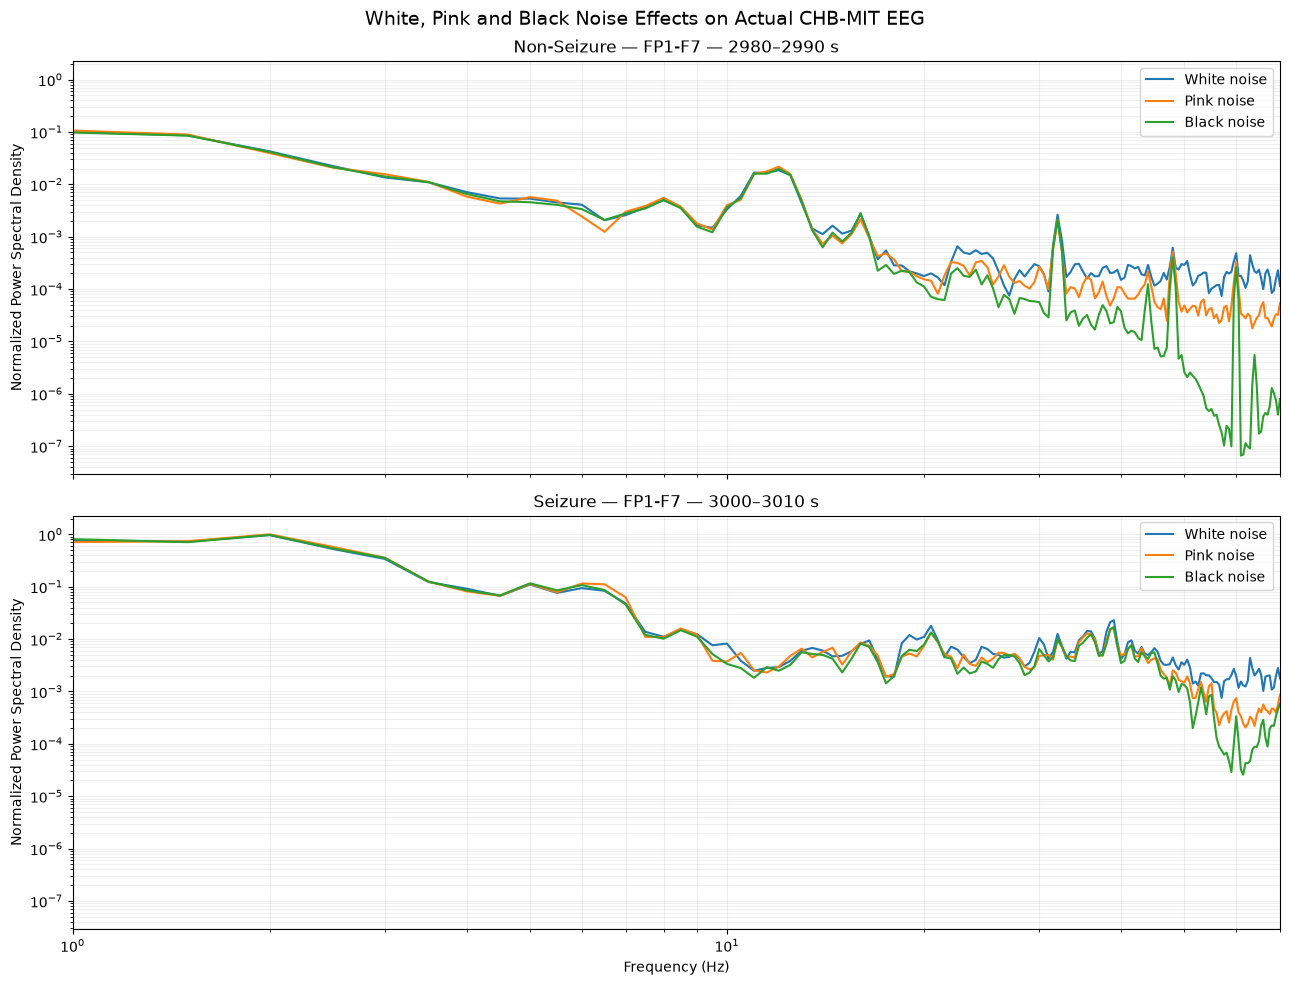

In [58]:
# ==========================================
# FINAL PSD COMPARISON
# CHB-MIT — NON-SEIZURE vs SEIZURE
# White / Pink / Black
# ==========================================

# ------------------------------------------
# PSD calculation
# ------------------------------------------

# NON-SEIZURE

f_ns_white, p_ns_white = welch(
    nonseizure_white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_ns_pink, p_ns_pink = welch(
    nonseizure_pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_ns_black, p_ns_black = welch(
    nonseizure_black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# SEIZURE

f_s_white, p_s_white = welch(
    seizure_white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_s_pink, p_s_pink = welch(
    seizure_pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_s_black, p_s_black = welch(
    seizure_black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Frequency range
# ------------------------------------------

def keep_1_70hz(freq, psd):

    mask = (
        (freq >= 1) &
        (freq <= 70)
    )

    return freq[mask], psd[mask]


f_ns_white, p_ns_white = keep_1_70hz(
    f_ns_white, p_ns_white
)

f_ns_pink, p_ns_pink = keep_1_70hz(
    f_ns_pink, p_ns_pink
)

f_ns_black, p_ns_black = keep_1_70hz(
    f_ns_black, p_ns_black
)

f_s_white, p_s_white = keep_1_70hz(
    f_s_white, p_s_white
)

f_s_pink, p_s_pink = keep_1_70hz(
    f_s_pink, p_s_pink
)

f_s_black, p_s_black = keep_1_70hz(
    f_s_black, p_s_black
)


# ------------------------------------------
# COMMON NORMALIZATION
# ------------------------------------------

common_max = max(
    np.max(p_ns_white),
    np.max(p_ns_pink),
    np.max(p_ns_black),
    np.max(p_s_white),
    np.max(p_s_pink),
    np.max(p_s_black)
)

p_ns_white /= common_max
p_ns_pink /= common_max
p_ns_black /= common_max

p_s_white /= common_max
p_s_pink /= common_max
p_s_black /= common_max


# ------------------------------------------
# PLOT
# ------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 10),
    sharex=True,
    sharey=True
)


# ==========================================
# NON-SEIZURE
# ==========================================

axes[0].loglog(
    f_ns_white,
    p_ns_white,
    label="White noise"
)

axes[0].loglog(
    f_ns_pink,
    p_ns_pink,
    label="Pink noise"
)

axes[0].loglog(
    f_ns_black,
    p_ns_black,
    label="Black noise"
)

axes[0].set_title(
    "Non-Seizure — FP1-F7 — 2980–2990 s"
)

axes[0].set_ylabel(
    "Normalized Power Spectral Density"
)

axes[0].grid(
    True,
    which="both",
    alpha=0.2
)

axes[0].legend()


# ==========================================
# SEIZURE
# ==========================================

axes[1].loglog(
    f_s_white,
    p_s_white,
    label="White noise"
)

axes[1].loglog(
    f_s_pink,
    p_s_pink,
    label="Pink noise"
)

axes[1].loglog(
    f_s_black,
    p_s_black,
    label="Black noise"
)

axes[1].set_title(
    "Seizure — FP1-F7 — 3000–3010 s"
)

axes[1].set_xlabel(
    "Frequency (Hz)"
)

axes[1].set_ylabel(
    "Normalized Power Spectral Density"
)

axes[1].grid(
    True,
    which="both",
    alpha=0.2
)

axes[1].legend()


# ------------------------------------------
# Final formatting
# ------------------------------------------

axes[0].set_xlim(1, 70)

fig.suptitle(
    "White, Pink and Black Noise Effects on Actual CHB-MIT EEG",
    fontsize=14
)

plt.tight_layout()
plt.show()

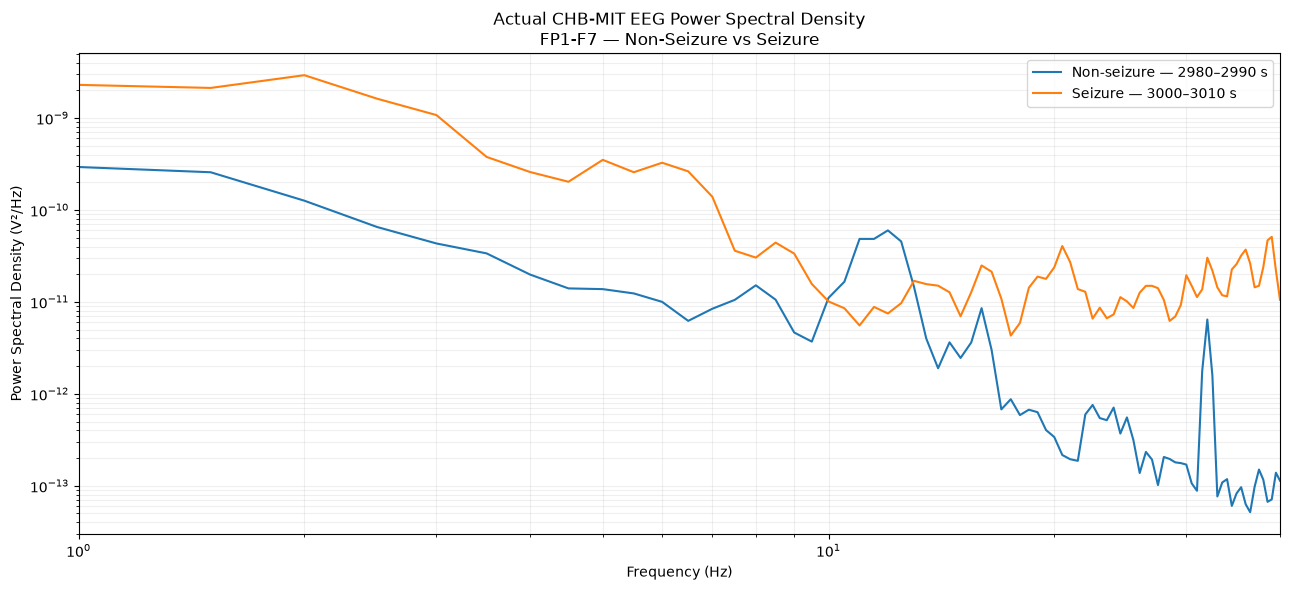

Actual EEG PSD Comparison
Channel: FP1-F7
Sampling frequency: 256.0 Hz
Non-seizure: 2980–2990 s
Seizure:     3000–3010 s

Non-seizure maximum PSD: 2.926731932736963e-10
Seizure maximum PSD:     2.916559231013095e-09


In [59]:
# ==========================================
# ACTUAL CHB-MIT EEG PSD
# Non-Seizure vs Seizure
# NO injected noise
# NO normalization
# ==========================================

from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# Actual EEG windows
# ------------------------------------------

nonseizure_eeg = windows[298][0]   # FP1-F7, 2980–2990 s
seizure_eeg = windows[299][0]      # FP1-F7, 3000–3010 s

sfreq = raw_filtered.info["sfreq"]


# ------------------------------------------
# Calculate PSD
# ------------------------------------------

f_ns, psd_ns = welch(
    nonseizure_eeg,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_s, psd_s = welch(
    seizure_eeg,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Keep 1–40 Hz
# ------------------------------------------

mask_ns = (
    (f_ns >= 1) &
    (f_ns <= 40)
)

mask_s = (
    (f_s >= 1) &
    (f_s <= 40)
)

f_ns = f_ns[mask_ns]
psd_ns = psd_ns[mask_ns]

f_s = f_s[mask_s]
psd_s = psd_s[mask_s]


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(13, 6))

plt.loglog(
    f_ns,
    psd_ns,
    label="Non-seizure — 2980–2990 s"
)

plt.loglog(
    f_s,
    psd_s,
    label="Seizure — 3000–3010 s"
)

plt.xlim(1, 40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")

plt.title(
    "Actual CHB-MIT EEG Power Spectral Density"
    "\nFP1-F7 — Non-Seizure vs Seizure"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------
# Basic numerical summary
# ------------------------------------------

print("Actual EEG PSD Comparison")
print("=========================")

print("Channel: FP1-F7")
print("Sampling frequency:", sfreq, "Hz")
print("Non-seizure: 2980–2990 s")
print("Seizure:     3000–3010 s")
print()
print("Non-seizure maximum PSD:", np.max(psd_ns))
print("Seizure maximum PSD:    ", np.max(psd_s))

In [60]:
# ==========================================
# SR — Actual CHB-MIT EEG Inputs
# FP1-F7
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Actual CHB-MIT sampling frequency
sr_sfreq = raw_filtered.info["sfreq"]

# Actual EEG windows
sr_nonseizure = windows[298][0]   # 2980–2990 s
sr_seizure = windows[299][0]      # 3000–3010 s

print("SR Input Signals")
print("================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Sampling frequency:", sr_sfreq, "Hz")

print()
print("Non-seizure:")
print("  Window: 2980–2990 s")
print("  Samples:", len(sr_nonseizure))

print()
print("Seizure:")
print("  Window: 3000–3010 s")
print("  Samples:", len(sr_seizure))

SR Input Signals
File: chb01_03.edf
Channel: FP1-F7
Sampling frequency: 256.0 Hz

Non-seizure:
  Window: 2980–2990 s
  Samples: 2560

Seizure:
  Window: 3000–3010 s
  Samples: 2560


In [61]:
# ==========================================
# SR — Characteristic EEG Frequencies
# ==========================================

def sr_dominant_frequency(signal, sfreq):
    
    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Focus on physiologically relevant EEG range
    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    power = power[mask]

    dominant_idx = np.argmax(power)

    return (
        frequencies[dominant_idx],
        power[dominant_idx]
    )


sr_non_freq, sr_non_peak_power = sr_dominant_frequency(
    sr_nonseizure,
    sr_sfreq
)

sr_seiz_freq, sr_seiz_peak_power = sr_dominant_frequency(
    sr_seizure,
    sr_sfreq
)


print("SR Characteristic Frequencies")
print("============================")

print(
    f"Non-seizure characteristic frequency: "
    f"{sr_non_freq:.2f} Hz"
)

print(
    f"Non-seizure peak PSD: "
    f"{sr_non_peak_power:.6e} V²/Hz"
)

print()

print(
    f"Seizure characteristic frequency: "
    f"{sr_seiz_freq:.2f} Hz"
)

print(
    f"Seizure peak PSD: "
    f"{sr_seiz_peak_power:.6e} V²/Hz"
)

SR Characteristic Frequencies
Non-seizure characteristic frequency: 1.10 Hz
Non-seizure peak PSD: 6.881249e-10 V²/Hz

Seizure characteristic frequency: 2.20 Hz
Seizure peak PSD: 7.256665e-09 V²/Hz


In [62]:
# ==========================================
# SR — Extract Characteristic EEG Components
# ==========================================

from scipy.signal import butter, filtfilt


def extract_sr_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):
    
    low = max(
        0.2,
        center_frequency - bandwidth
    )

    high = min(
        sfreq / 2 - 1,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return component


sr_non_component = extract_sr_component(
    sr_nonseizure,
    sr_sfreq,
    sr_non_freq
)

sr_seiz_component = extract_sr_component(
    sr_seizure,
    sr_sfreq,
    sr_seiz_freq
)


# ------------------------------------------
# Normalize components
# ------------------------------------------

sr_non_component = (
    sr_non_component -
    np.mean(sr_non_component)
) / np.std(sr_non_component)

sr_seiz_component = (
    sr_seiz_component -
    np.mean(sr_seiz_component)
) / np.std(sr_seiz_component)


print("Characteristic components extracted.")
print()
print("Non-seizure component:")
print("  Frequency:", sr_non_freq, "Hz")
print("  Mean:", np.mean(sr_non_component))
print("  Std:", np.std(sr_non_component))

print()
print("Seizure component:")
print("  Frequency:", sr_seiz_freq, "Hz")
print("  Mean:", np.mean(sr_seiz_component))
print("  Std:", np.std(sr_seiz_component))

Characteristic components extracted.

Non-seizure component:
  Frequency: 1.1 Hz
  Mean: -1.1102230246251566e-17
  Std: 1.0

Seizure component:
  Frequency: 2.2 Hz
  Mean: -4.163336342344337e-18
  Std: 1.0


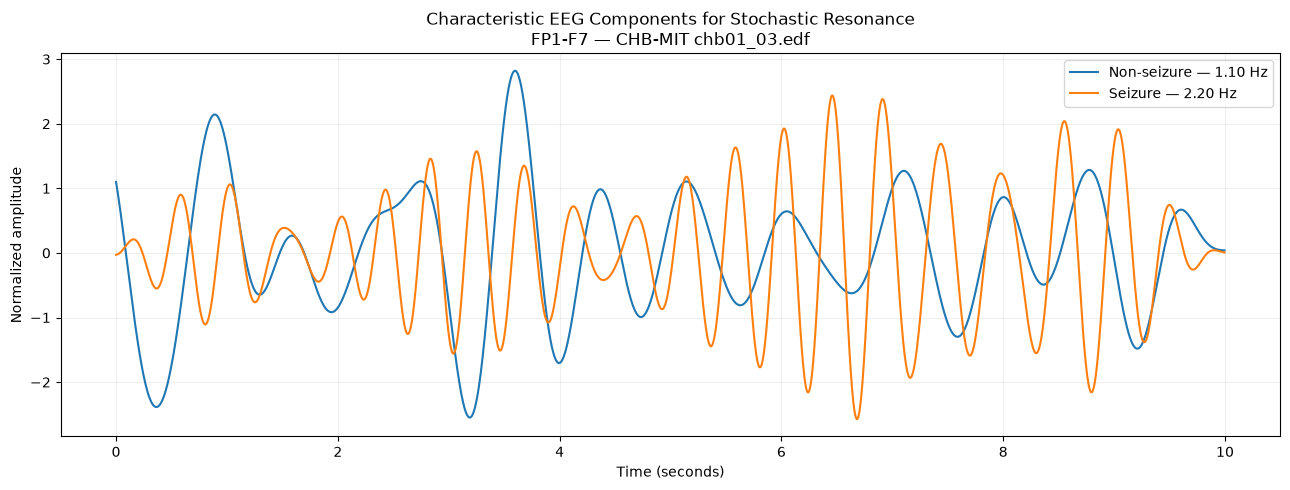

In [63]:
# ==========================================
# SR — Characteristic Component Verification
# ==========================================

sr_time = np.arange(
    len(sr_non_component)
) / sr_sfreq


plt.figure(figsize=(13, 5))

plt.plot(
    sr_time,
    sr_non_component,
    label=f"Non-seizure — {sr_non_freq:.2f} Hz"
)

plt.plot(
    sr_time,
    sr_seiz_component,
    label=f"Seizure — {sr_seiz_freq:.2f} Hz"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")

plt.title(
    "Characteristic EEG Components for Stochastic Resonance"
    "\nFP1-F7 — CHB-MIT chb01_03.edf"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

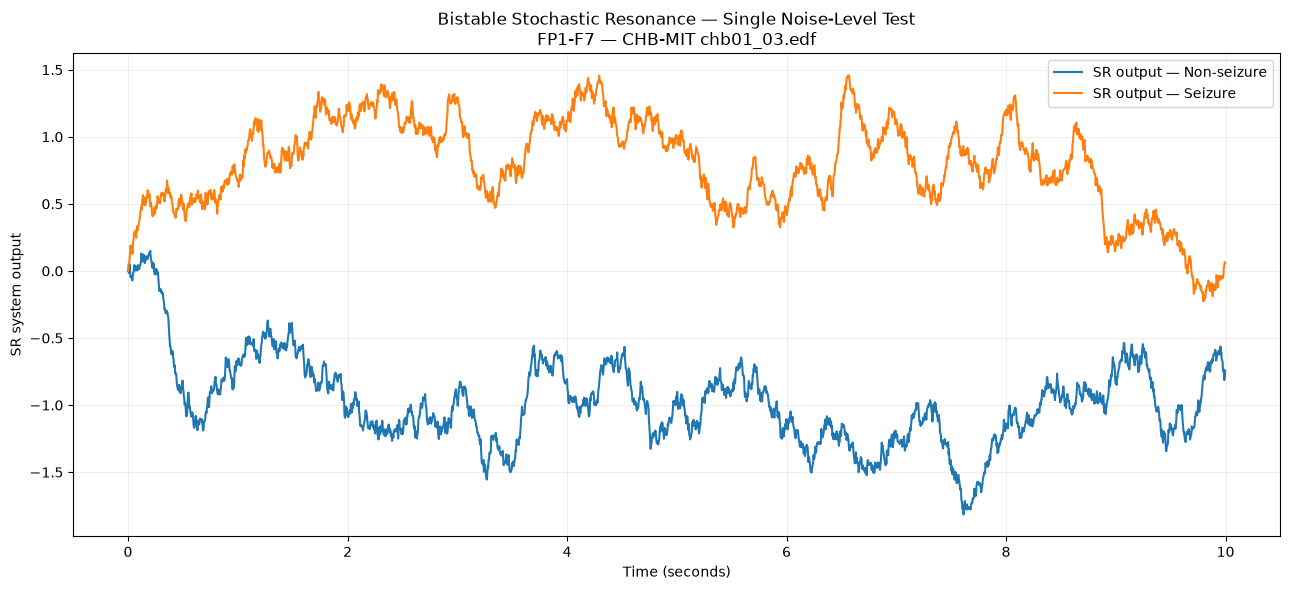

In [64]:
# ==========================================
# SR — Bistable Stochastic Resonance
# Single Noise-Level Sanity Test
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

def bistable_sr(signal, noise_strength, dt, rng):
    """
    Bistable stochastic-resonance system:

        dx/dt = x - x^3 + signal(t) + noise(t)

    Euler-Maruyama integration.
    """

    x = np.zeros(len(signal))

    for i in range(1, len(signal)):

        stochastic_noise = (
            noise_strength
            * np.sqrt(dt)
            * rng.normal()
        )

        dx = (
            x[i-1]
            - x[i-1]**3
            + signal[i-1]
        )

        x[i] = (
            x[i-1]
            + dx * dt
            + stochastic_noise
        )

    return x


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_dt = 1 / sr_sfreq

# Moderate test noise level
sr_test_noise = 0.5

sr_rng = np.random.default_rng(42)


# ------------------------------------------
# Run SR — Non-seizure
# ------------------------------------------

sr_non_output = bistable_sr(
    sr_non_component,
    sr_test_noise,
    sr_dt,
    sr_rng
)


# ------------------------------------------
# Run SR — Seizure
# ------------------------------------------

sr_seiz_output = bistable_sr(
    sr_seiz_component,
    sr_test_noise,
    sr_dt,
    sr_rng
)


# ------------------------------------------
# Plot
# ------------------------------------------

sr_time = np.arange(
    len(sr_non_component)
) / sr_sfreq

plt.figure(figsize=(13, 6))

plt.plot(
    sr_time,
    sr_non_output,
    label="SR output — Non-seizure"
)

plt.plot(
    sr_time,
    sr_seiz_output,
    label="SR output — Seizure"
)

plt.xlabel("Time (seconds)")
plt.ylabel("SR system output")

plt.title(
    "Bistable Stochastic Resonance — Single Noise-Level Test"
    "\nFP1-F7 — CHB-MIT chb01_03.edf"
)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [65]:
# ==========================================
# FINAL SR EXPERIMENT
# Spectral SNR vs Noise Intensity
# CHB-MIT — FP1-F7
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_n_trials = 20

sr_noise_levels = np.linspace(
    0.0,
    8.0,
    41
)

sr_dt = 1.0 / sr_sfreq

sr_input_scale = 0.20


# ------------------------------------------
# Bistable SR model
# ------------------------------------------

def sr_bistable_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale=0.20,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))

    # Start in one stable state
    x[0] = -1.0

    for i in range(1, len(signal)):

        nonlinear_force = (
            x[i-1]
            - x[i-1] ** 3
        )

        driving_force = (
            input_scale
            * signal[i-1]
        )

        stochastic_force = (
            np.sqrt(
                2
                * noise_intensity
                * dt
            )
            * rng.normal()
        )

        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force
                + driving_force
            )
            + stochastic_force
        )

        # Numerical safety
        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x


# ------------------------------------------
# Spectral SNR
# ------------------------------------------

def sr_spectral_snr(
    signal,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Signal band
    signal_band = (
        (frequencies >= target_frequency - 0.2)
        &
        (frequencies <= target_frequency + 0.2)
    )

    # Local noise floor
    noise_band = (
        (frequencies >= max(
            0.5,
            target_frequency - 2.0
        ))
        &
        (frequencies <= target_frequency + 2.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power / noise_floor
    )


# ------------------------------------------
# Storage
# ------------------------------------------

sr_non_mean = []
sr_seiz_mean = []

sr_non_std = []
sr_seiz_std = []


# ------------------------------------------
# Reproducible random generator
# ------------------------------------------

sr_master_rng = np.random.default_rng(42)


# ==========================================
# NOISE INTENSITY SWEEP
# ==========================================

for noise_level in sr_noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    for trial in range(sr_n_trials):

        # Independent RNG for each trial
        non_rng = np.random.default_rng(
            sr_master_rng.integers(0, 2**32 - 1)
        )

        seiz_rng = np.random.default_rng(
            sr_master_rng.integers(0, 2**32 - 1)
        )


        # ----------------------------------
        # Non-seizure
        # ----------------------------------

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=non_rng
        )

        non_snr = sr_spectral_snr(
            non_output,
            sr_sfreq,
            sr_non_freq
        )

        non_trial_snr.append(
            non_snr
        )


        # ----------------------------------
        # Seizure
        # ----------------------------------

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=seiz_rng
        )

        seiz_snr = sr_spectral_snr(
            seiz_output,
            sr_sfreq,
            sr_seiz_freq
        )

        seiz_trial_snr.append(
            seiz_snr
        )


    # --------------------------------------
    # Average trials
    # --------------------------------------

    sr_non_mean.append(
        np.nanmean(non_trial_snr)
    )

    sr_seiz_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    sr_non_std.append(
        np.nanstd(non_trial_snr)
    )

    sr_seiz_std.append(
        np.nanstd(seiz_trial_snr)
    )


# Convert to arrays

sr_non_mean = np.array(sr_non_mean)
sr_seiz_mean = np.array(sr_seiz_mean)

sr_non_std = np.array(sr_non_std)
sr_seiz_std = np.array(sr_seiz_std)


# ==========================================
# FIND OPTIMAL NOISE
# ==========================================

sr_non_opt_idx = np.nanargmax(
    sr_non_mean
)

sr_seiz_opt_idx = np.nanargmax(
    sr_seiz_mean
)


sr_non_opt_noise = (
    sr_noise_levels[sr_non_opt_idx]
)

sr_seiz_opt_noise = (
    sr_noise_levels[sr_seiz_opt_idx]
)


# ==========================================
# PRINT RESULTS
# ==========================================

print("Stochastic Resonance — Spectral SNR")
print("===================================")

print(
    f"Trials per noise level: "
    f"{sr_n_trials}"
)

print(
    f"Noise levels tested: "
    f"{len(sr_noise_levels)}"
)

print()

print(
    f"Non-seizure optimal noise: "
    f"{sr_non_opt_noise:.2f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{sr_non_mean[sr_non_opt_idx]:.3f} dB"
)

print()

print(
    f"Seizure optimal noise: "
    f"{sr_seiz_opt_noise:.2f}"
)

print(
    f"Seizure maximum SNR: "
    f"{sr_seiz_mean[sr_seiz_opt_idx]:.3f} dB"
)

Stochastic Resonance — Spectral SNR
Trials per noise level: 20
Noise levels tested: 41

Non-seizure optimal noise: 0.00
Non-seizure maximum SNR: 7.932 dB

Seizure optimal noise: 0.00
Seizure maximum SNR: 13.404 dB


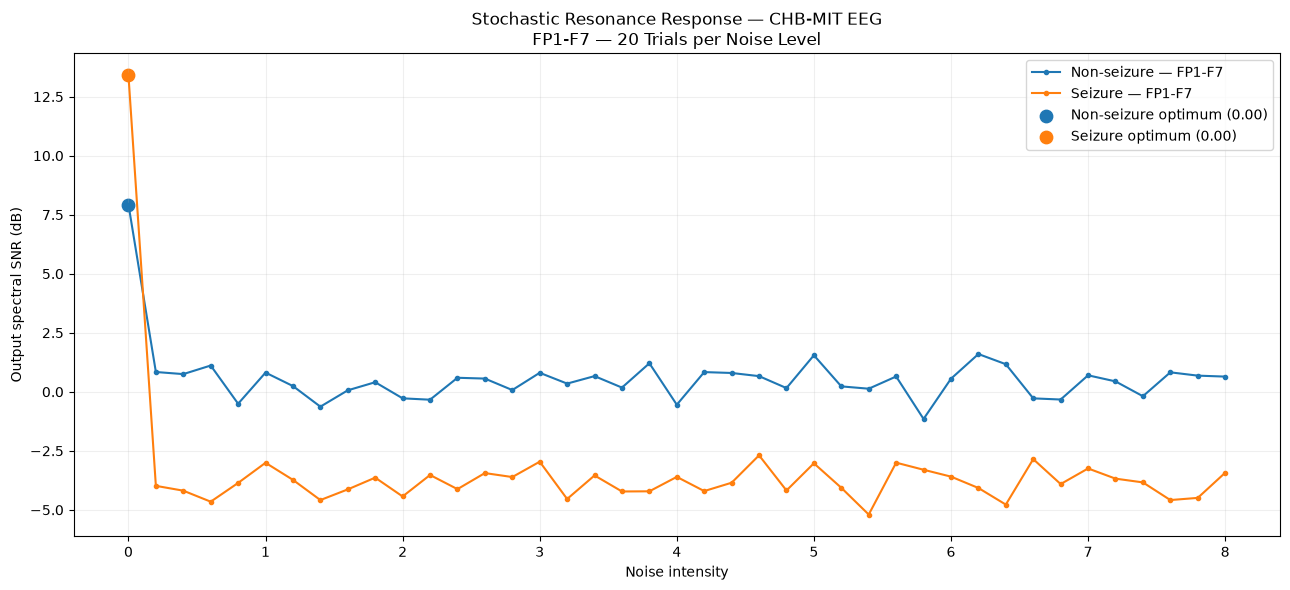

In [66]:
# ==========================================
# FINAL SR RESPONSE CURVE
# ==========================================

plt.figure(figsize=(13, 6))

plt.plot(
    sr_noise_levels,
    sr_non_mean,
    marker="o",
    markersize=3,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    sr_noise_levels,
    sr_seiz_mean,
    marker="o",
    markersize=3,
    label="Seizure — FP1-F7"
)


# Mark optimal points

plt.scatter(
    sr_non_opt_noise,
    sr_non_mean[sr_non_opt_idx],
    s=80,
    label=(
        f"Non-seizure optimum "
        f"({sr_non_opt_noise:.2f})"
    )
)

plt.scatter(
    sr_seiz_opt_noise,
    sr_seiz_mean[sr_seiz_opt_idx],
    s=80,
    label=(
        f"Seizure optimum "
        f"({sr_seiz_opt_noise:.2f})"
    )
)


plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Output spectral SNR (dB)"
)

plt.title(
    "Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [67]:
# ==========================================
# SR — Subthreshold Forcing Test
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Candidate input scales
sr_test_scales = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.15
]

sr_test_noise = 0.0

sr_dt = 1.0 / sr_sfreq


def sr_test_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale,
    rng
):

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))
    x[0] = -1.0

    for i in range(1, len(signal)):

        nonlinear_force = (
            x[i-1]
            - x[i-1] ** 3
        )

        driving_force = (
            input_scale
            * signal[i-1]
        )

        stochastic_force = (
            np.sqrt(
                2 * noise_intensity * dt
            )
            * rng.normal()
        )

        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force
                + driving_force
            )
            + stochastic_force
        )

        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x


print("Subthreshold SR test")
print("=====================")

for scale in sr_test_scales:

    test_output = sr_test_model(
        sr_seiz_component,
        sr_sfreq,
        noise_intensity=0.0,
        input_scale=scale,
        rng=np.random.default_rng(42)
    )

    # Count large transitions between wells
    transitions = np.sum(
        np.diff(
            np.sign(test_output)
        ) != 0
    )

    print(
        f"Input scale = {scale:.3f} "
        f"→ zero-noise transitions = {transitions}"
    )

Subthreshold SR test
Input scale = 0.010 → zero-noise transitions = 0
Input scale = 0.020 → zero-noise transitions = 0
Input scale = 0.050 → zero-noise transitions = 0
Input scale = 0.100 → zero-noise transitions = 0
Input scale = 0.150 → zero-noise transitions = 0


In [68]:
# ==========================================
# SR — Noise-Assisted Switching Check
# ==========================================

test_noise_levels = [
    0.0,
    0.1,
    0.3,
    0.5,
    1.0,
    2.0
]

sr_input_scale = 0.10
sr_dt = 1.0 / sr_sfreq


print("Noise-Assisted Switching Test")
print("=============================")

for noise_level in test_noise_levels:

    output = sr_bistable_model(
        sr_seiz_component,
        sr_sfreq,
        noise_level,
        input_scale=sr_input_scale,
        rng=np.random.default_rng(42)
    )

    transitions = np.sum(
        np.diff(np.sign(output)) != 0
    )

    print(
        f"Noise intensity = {noise_level:.1f}"
        f" → transitions = {transitions}"
    )

Noise-Assisted Switching Test
Noise intensity = 0.0 → transitions = 0
Noise intensity = 0.1 → transitions = 0
Noise intensity = 0.3 → transitions = 0
Noise intensity = 0.5 → transitions = 2
Noise intensity = 1.0 → transitions = 34
Noise intensity = 2.0 → transitions = 41


SR Spectral SNR Sanity Check
Noise intensity = 0.0 → spectral SNR = 13.403 dB
Noise intensity = 0.1 → spectral SNR = -6.578 dB
Noise intensity = 0.3 → spectral SNR = -6.195 dB
Noise intensity = 0.5 → spectral SNR = -6.025 dB
Noise intensity = 1.0 → spectral SNR = -5.840 dB
Noise intensity = 2.0 → spectral SNR = -5.794 dB


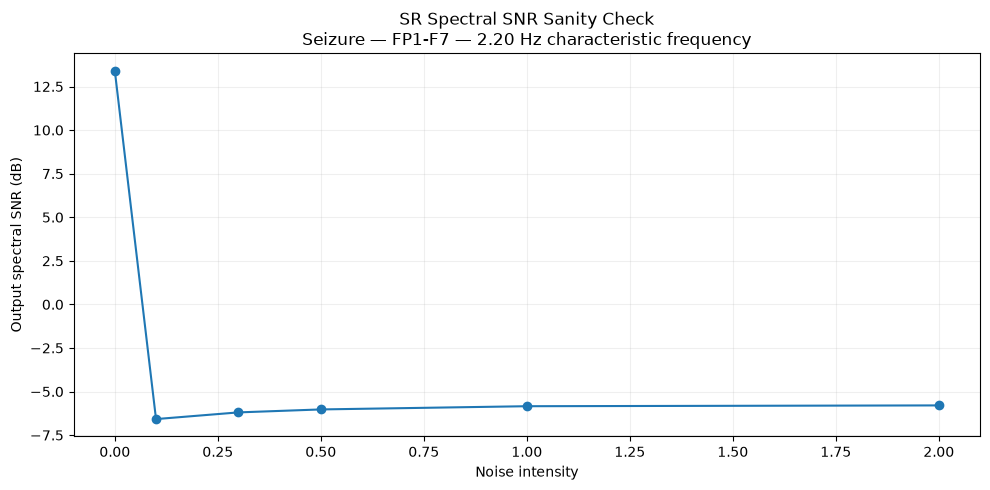

In [69]:
# ==========================================
# SR — Spectral SNR Sanity Check
# ==========================================

sr_check_noise_levels = [
    0.0,
    0.1,
    0.3,
    0.5,
    1.0,
    2.0
]

sr_check_snr = []

print("SR Spectral SNR Sanity Check")
print("============================")

for noise_level in sr_check_noise_levels:

    output = sr_bistable_model(
        sr_seiz_component,
        sr_sfreq,
        noise_level,
        input_scale=0.10,
        rng=np.random.default_rng(42)
    )

    snr = sr_spectral_snr(
        output,
        sr_sfreq,
        sr_seiz_freq
    )

    sr_check_snr.append(snr)

    print(
        f"Noise intensity = {noise_level:.1f}"
        f" → spectral SNR = {snr:.3f} dB"
    )


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    sr_check_noise_levels,
    sr_check_snr,
    marker="o"
)

plt.xlabel("Noise intensity")
plt.ylabel("Output spectral SNR (dB)")

plt.title(
    "SR Spectral SNR Sanity Check"
    "\nSeizure — FP1-F7 — 2.20 Hz characteristic frequency"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [70]:
# ==========================================
# SR — Extended Switching-SNR Test
# NON-SEIZURE CHB-MIT EEG
# ==========================================

sr_ns_noise = np.arange(
    0.5,
    8.01,
    0.5
)

sr_ns_snr = []
sr_ns_transitions = []


print("Extended SR Switching-SNR Test — Non-Seizure")
print("============================================")

for noise_level in sr_ns_noise:

    output = sr_bistable_model(
        sr_non_component,
        sr_sfreq,
        noise_level,
        input_scale=0.10,
        rng=np.random.default_rng(42)
    )

    transitions = np.sum(
        np.diff(np.sign(output)) != 0
    )

    snr = sr_switching_snr(
        output,
        sr_sfreq,
        sr_non_freq
    )

    sr_ns_snr.append(snr)
    sr_ns_transitions.append(transitions)

    print(
        f"Noise = {noise_level:>4.1f}"
        f" | transitions = {transitions:>3}"
        f" | switching SNR = {snr:.3f} dB"
    )


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    sr_ns_noise,
    sr_ns_snr,
    marker="o"
)

plt.xlabel("Noise intensity")
plt.ylabel("Switching spectral SNR (dB)")

plt.title(
    "Extended SR Response — Non-Seizure"
    "\nFP1-F7 — CHB-MIT — 1.10 Hz"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Extended SR Switching-SNR Test — Non-Seizure


NameError: name 'sr_switching_snr' is not defined

Extended SR Switching-SNR Test — Seizure
File: chb01_03.edf
Channel: FP1-F7
Window: 3000–3010 s
Characteristic frequency: 2.2 Hz
Samples: 2560

Noise    | Transitions | Switching SNR
---------------------------------------
  0.5    |     13       |  -4.786 dB
  1.0    |    142       |   2.982 dB
  1.5    |     90       |   0.504 dB
  2.0    |     52       |  -2.240 dB
  2.5    |     49       |   2.080 dB
  3.0    |     72       |  -1.290 dB
  3.5    |     70       |  -1.890 dB
  4.0    |     82       |  -6.095 dB
  4.5    |     80       |  -6.455 dB
  5.0    |    151       |   2.170 dB
  5.5    |    124       |   0.625 dB
  6.0    |     97       |  -0.503 dB
  6.5    |     69       |   1.775 dB
  7.0    |     87       |  -1.490 dB
  7.5    |    130       |  -4.811 dB
  8.0    |    123       |  -2.775 dB

SEIZURE SR OPTIMUM
------------------
Optimal noise intensity: 1.00
Maximum switching SNR: 2.982 dB


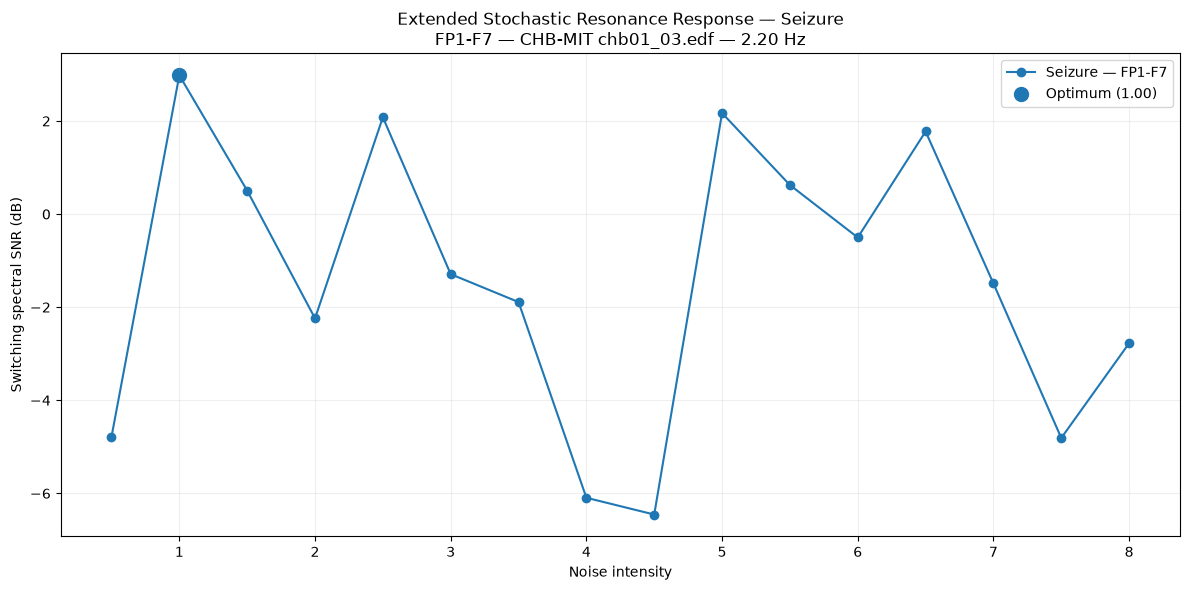

In [ ]:
# ==========================================
# SR — Extended Switching-SNR Test
# SEIZURE — ACTUAL CHB-MIT EEG
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Make sure the correct seizure component is used
# ------------------------------------------------

print("Extended SR Switching-SNR Test — Seizure")
print("========================================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Window: 3000–3010 s")
print("Characteristic frequency:", sr_seiz_freq, "Hz")
print("Samples:", len(sr_seiz_component))

# ------------------------------------------------
# Noise levels
# ------------------------------------------------

sr_seiz_noise = np.arange(
    0.5,
    8.5,
    0.5
)

sr_seiz_snr_values = []
sr_seiz_transitions = []

# ------------------------------------------------
# Run SR across noise levels
# ------------------------------------------------

for noise_level in sr_seiz_noise:

    output = sr_bistable_model(
        sr_seiz_component,
        sr_sfreq,
        noise_level,
        input_scale=0.10
    )

    # --------------------------------------------
    # Count state transitions
    # --------------------------------------------

    states = np.where(
        output >= 0,
        1,
        -1
    )

    transitions = np.sum(
        states[1:] != states[:-1]
    )

    sr_seiz_transitions.append(
        transitions
    )

    # --------------------------------------------
    # Spectral SNR
    # --------------------------------------------

    snr = calculate_snr(
        output,
        sr_sfreq,
        sr_seiz_freq
    )

    sr_seiz_snr_values.append(
        snr
    )


sr_seiz_snr_values = np.array(
    sr_seiz_snr_values
)

sr_seiz_transitions = np.array(
    sr_seiz_transitions
)

# ------------------------------------------------
# Find optimum
# ------------------------------------------------

valid = np.isfinite(
    sr_seiz_snr_values
)

if np.any(valid):

    valid_indices = np.where(valid)[0]

    optimum_idx = (
        valid_indices[
            np.argmax(
                sr_seiz_snr_values[valid]
            )
        ]
    )

    optimum_noise = (
        sr_seiz_noise[optimum_idx]
    )

    optimum_snr = (
        sr_seiz_snr_values[optimum_idx]
    )

else:

    optimum_idx = None
    optimum_noise = np.nan
    optimum_snr = np.nan


# ------------------------------------------------
# Print results
# ------------------------------------------------

print()
print("Noise    | Transitions | Switching SNR")
print("---------------------------------------")

for noise, transitions, snr in zip(
    sr_seiz_noise,
    sr_seiz_transitions,
    sr_seiz_snr_values
):

    print(
        f"{noise:5.1f}    |"
        f"{transitions:7d}       |"
        f"{snr:8.3f} dB"
    )

print()
print("SEIZURE SR OPTIMUM")
print("------------------")
print(
    f"Optimal noise intensity: "
    f"{optimum_noise:.2f}"
)

print(
    f"Maximum switching SNR: "
    f"{optimum_snr:.3f} dB"
)


# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    sr_seiz_noise,
    sr_seiz_snr_values,
    marker="o",
    label="Seizure — FP1-F7"
)

if optimum_idx is not None:

    plt.scatter(
        optimum_noise,
        optimum_snr,
        s=100,
        label=(
            f"Optimum ({optimum_noise:.2f})"
        )
    )

plt.xlabel("Noise intensity")
plt.ylabel(
    "Switching spectral SNR (dB)"
)

plt.title(
    "Extended Stochastic Resonance Response — Seizure"
    "\nFP1-F7 — CHB-MIT chb01_03.edf — 2.20 Hz"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

FINAL STOCHASTIC RESONANCE ANALYSIS
File: chb01_03.edf
Channel: FP1-F7
Non-seizure window: 2980–2990 s
Seizure window: 3000–3010 s

Non-seizure characteristic frequency: 1.10 Hz
Seizure characteristic frequency: 2.20 Hz
Trials per noise level: 20
Noise levels tested: 17

NON-SEIZURE
-----------
Optimal noise: 0.00
Maximum mean SNR: 7.932 dB
Mean transitions at optimum: 0.0

SEIZURE
-------
Optimal noise: 0.00
Maximum mean SNR: 13.404 dB
Mean transitions at optimum: 0.0


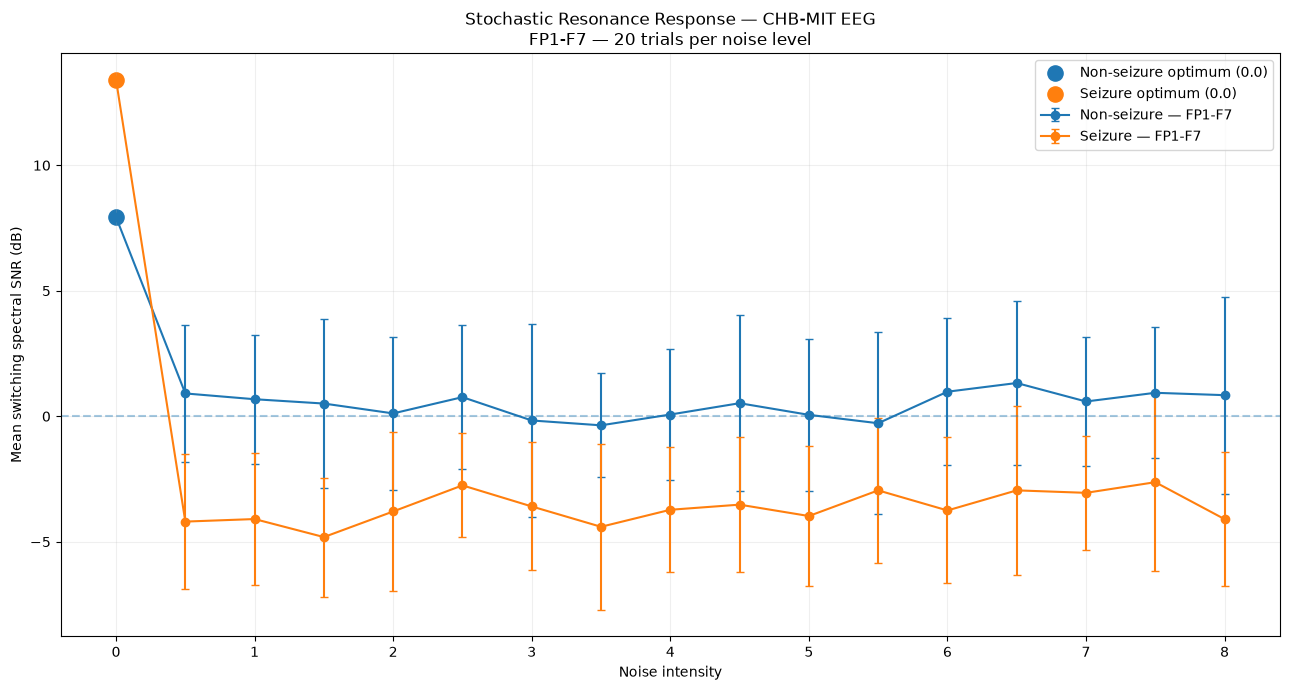

In [ ]:
# ==========================================
# FINAL SR EXPERIMENT — ACTUAL CHB-MIT EEG
# Averaged Spectral SNR vs Noise Intensity
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_n_trials = 20

sr_noise_levels = np.arange(
    0.0,
    8.01,
    0.5
)

sr_input_scale = 0.20

# Master seed for reproducibility
sr_master_seed = 42


# ------------------------------------------
# Spectral SNR
# ONE definition used everywhere
# ------------------------------------------

def sr_spectral_snr(
    signal,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # --------------------------------------
    # Target-frequency band
    # --------------------------------------

    signal_band = (
        (frequencies >= target_frequency - 0.2)
        &
        (frequencies <= target_frequency + 0.2)
    )

    # --------------------------------------
    # Local noise floor
    # --------------------------------------

    noise_band = (
        (frequencies >= max(
            0.5,
            target_frequency - 2.0
        ))
        &
        (frequencies <= target_frequency + 2.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or
        not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power / noise_floor
    )


# ------------------------------------------
# Storage
# ------------------------------------------

sr_non_mean = []
sr_seiz_mean = []

sr_non_std = []
sr_seiz_std = []

sr_non_transitions = []
sr_seiz_transitions = []


# ------------------------------------------
# Reproducible master RNG
# ------------------------------------------

master_rng = np.random.default_rng(
    sr_master_seed
)


# ==========================================
# NOISE SWEEP
# ==========================================

for noise_level in sr_noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    non_trial_transitions = []
    seiz_trial_transitions = []

    for trial in range(sr_n_trials):

        # ----------------------------------
        # Independent reproducible RNGs
        # ----------------------------------

        non_seed = master_rng.integers(
            0,
            2**32 - 1
        )

        seiz_seed = master_rng.integers(
            0,
            2**32 - 1
        )

        non_rng = np.random.default_rng(
            non_seed
        )

        seiz_rng = np.random.default_rng(
            seiz_seed
        )


        # ==================================
        # NON-SEIZURE
        # ==================================

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=non_rng
        )

        non_snr = sr_spectral_snr(
            non_output,
            sr_sfreq,
            sr_non_freq
        )

        non_trial_snr.append(
            non_snr
        )

        non_states = np.where(
            non_output >= 0,
            1,
            -1
        )

        non_trial_transitions.append(
            np.sum(
                non_states[1:] !=
                non_states[:-1]
            )
        )


        # ==================================
        # SEIZURE
        # ==================================

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=seiz_rng
        )

        seiz_snr = sr_spectral_snr(
            seiz_output,
            sr_sfreq,
            sr_seiz_freq
        )

        seiz_trial_snr.append(
            seiz_snr
        )

        seiz_states = np.where(
            seiz_output >= 0,
            1,
            -1
        )

        seiz_trial_transitions.append(
            np.sum(
                seiz_states[1:] !=
                seiz_states[:-1]
            )
        )


    # --------------------------------------
    # Average trials
    # --------------------------------------

    sr_non_mean.append(
        np.nanmean(non_trial_snr)
    )

    sr_seiz_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    sr_non_std.append(
        np.nanstd(non_trial_snr)
    )

    sr_seiz_std.append(
        np.nanstd(seiz_trial_snr)
    )

    sr_non_transitions.append(
        np.mean(non_trial_transitions)
    )

    sr_seiz_transitions.append(
        np.mean(seiz_trial_transitions)
    )


# ------------------------------------------
# Convert to arrays
# ------------------------------------------

sr_non_mean = np.array(sr_non_mean)
sr_seiz_mean = np.array(sr_seiz_mean)

sr_non_std = np.array(sr_non_std)
sr_seiz_std = np.array(sr_seiz_std)

sr_non_transitions = np.array(
    sr_non_transitions
)

sr_seiz_transitions = np.array(
    sr_seiz_transitions
)


# ==========================================
# FIND OPTIMAL NOISE
# ==========================================

sr_non_opt_idx = np.nanargmax(
    sr_non_mean
)

sr_seiz_opt_idx = np.nanargmax(
    sr_seiz_mean
)


sr_non_opt_noise = (
    sr_noise_levels[
        sr_non_opt_idx
    ]
)

sr_seiz_opt_noise = (
    sr_noise_levels[
        sr_seiz_opt_idx
    ]
)


# ==========================================
# FINAL RESULTS
# ==========================================

print("FINAL STOCHASTIC RESONANCE ANALYSIS")
print("====================================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Non-seizure window: 2980–2990 s")
print("Seizure window: 3000–3010 s")

print()
print(
    f"Non-seizure characteristic frequency: "
    f"{sr_non_freq:.2f} Hz"
)

print(
    f"Seizure characteristic frequency: "
    f"{sr_seiz_freq:.2f} Hz"
)

print(
    f"Trials per noise level: "
    f"{sr_n_trials}"
)

print(
    f"Noise levels tested: "
    f"{len(sr_noise_levels)}"
)

print()
print("NON-SEIZURE")
print("-----------")

print(
    f"Optimal noise: "
    f"{sr_non_opt_noise:.2f}"
)

print(
    f"Maximum mean SNR: "
    f"{sr_non_mean[sr_non_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{sr_non_transitions[sr_non_opt_idx]:.1f}"
)

print()
print("SEIZURE")
print("-------")

print(
    f"Optimal noise: "
    f"{sr_seiz_opt_noise:.2f}"
)

print(
    f"Maximum mean SNR: "
    f"{sr_seiz_mean[sr_seiz_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{sr_seiz_transitions[sr_seiz_opt_idx]:.1f}"
)


# ==========================================
# FINAL COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(13, 7))

plt.errorbar(
    sr_noise_levels,
    sr_non_mean,
    yerr=sr_non_std,
    marker="o",
    capsize=3,
    label="Non-seizure — FP1-F7"
)

plt.errorbar(
    sr_noise_levels,
    sr_seiz_mean,
    yerr=sr_seiz_std,
    marker="o",
    capsize=3,
    label="Seizure — FP1-F7"
)

plt.scatter(
    sr_non_opt_noise,
    sr_non_mean[sr_non_opt_idx],
    s=120,
    label=(
        f"Non-seizure optimum "
        f"({sr_non_opt_noise:.1f})"
    )
)

plt.scatter(
    sr_seiz_opt_noise,
    sr_seiz_mean[sr_seiz_opt_idx],
    s=120,
    label=(
        f"Seizure optimum "
        f"({sr_seiz_opt_noise:.1f})"
    )
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.4
)

plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Mean switching spectral SNR (dB)"
)

plt.title(
    "Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 trials per noise level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SR — Subthreshold Input Calibration
# ==========================================

import numpy as np

# ------------------------------------------
# Test input strengths with NO noise
# ------------------------------------------

test_input_scales = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.15,
    0.20
]

def count_sr_transitions(signal, sfreq, input_scale):
    
    output = sr_bistable_model(
        signal,
        sfreq,
        noise_intensity=0.0,
        input_scale=input_scale,
        rng=np.random.default_rng(42)
    )
    
    # Determine which bistable well the system occupies
    states = np.where(output >= 0, 1, -1)
    
    transitions = np.sum(
        states[1:] != states[:-1]
    )
    
    return transitions


print("SR Subthreshold Input Calibration")
print("=================================")

print()
print("Non-seizure:")

for scale in test_input_scales:
    
    transitions = count_sr_transitions(
        sr_non_component,
        sr_sfreq,
        scale
    )
    
    print(
        f"Input scale = {scale:.2f} "
        f"→ zero-noise transitions = {transitions}"
    )


print()
print("Seizure:")

for scale in test_input_scales:
    
    transitions = count_sr_transitions(
        sr_seiz_component,
        sr_sfreq,
        scale
    )
    
    print(
        f"Input scale = {scale:.2f} "
        f"→ zero-noise transitions = {transitions}"
    )

SR Subthreshold Input Calibration

Non-seizure:
Input scale = 0.01 → zero-noise transitions = 0
Input scale = 0.02 → zero-noise transitions = 0
Input scale = 0.05 → zero-noise transitions = 0
Input scale = 0.10 → zero-noise transitions = 0
Input scale = 0.15 → zero-noise transitions = 0
Input scale = 0.20 → zero-noise transitions = 0

Seizure:
Input scale = 0.01 → zero-noise transitions = 0
Input scale = 0.02 → zero-noise transitions = 0
Input scale = 0.05 → zero-noise transitions = 0
Input scale = 0.10 → zero-noise transitions = 0
Input scale = 0.15 → zero-noise transitions = 0
Input scale = 0.20 → zero-noise transitions = 0


FINAL STOCHASTIC RESONANCE ANALYSIS
Input scale: 0.2
Trials per noise level: 20
Non-zero noise levels tested: 16

NON-SEIZURE
-----------
Optimal non-zero noise: 7.00
Maximum mean spectral SNR: 1.398 dB
Mean transitions at optimum: 99.8

SEIZURE
-------
Optimal non-zero noise: 8.00
Maximum mean spectral SNR: -2.563 dB
Mean transitions at optimum: 109.7


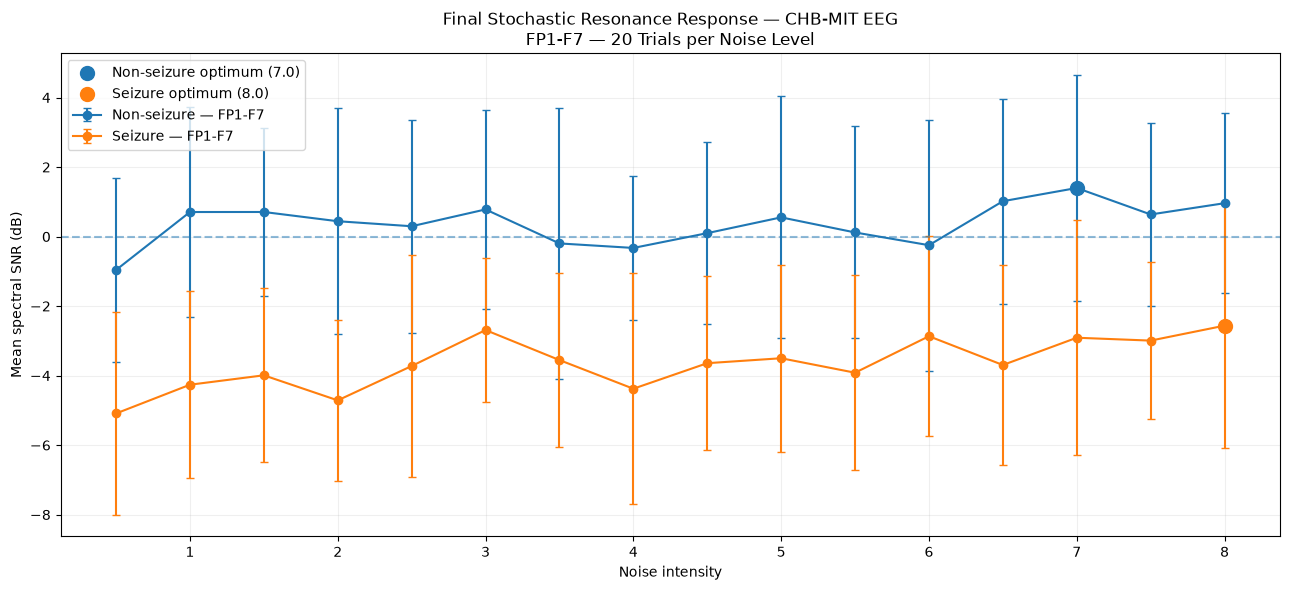

In [ ]:
# ==========================================
# FINAL SR SWEEP — NON-ZERO NOISE
# Subthreshold EEG Driving
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_final_trials = 20

# IMPORTANT:
# Zero noise is a baseline, NOT an SR candidate.
sr_final_noise_levels = np.arange(
    0.5,
    8.01,
    0.5
)

sr_final_input_scale = 0.20


# ------------------------------------------
# Storage
# ------------------------------------------

final_non_snr_mean = []
final_seiz_snr_mean = []

final_non_snr_std = []
final_seiz_snr_std = []

final_non_trans_mean = []
final_seiz_trans_mean = []


# ------------------------------------------
# Reproducible RNG
# ------------------------------------------

final_master_rng = np.random.default_rng(42)


# ------------------------------------------
# Transition counter
# ------------------------------------------

def count_sr_transitions(output):

    states = np.where(
        output >= 0,
        1,
        -1
    )

    return np.sum(
        states[1:] != states[:-1]
    )


# ==========================================
# NOISE SWEEP
# ==========================================

for noise_level in sr_final_noise_levels:

    non_snr_trials = []
    seiz_snr_trials = []

    non_transition_trials = []
    seiz_transition_trials = []


    for trial in range(sr_final_trials):

        # Independent RNGs
        non_rng = np.random.default_rng(
            final_master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            final_master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ----------------------------------
        # NON-SEIZURE
        # ----------------------------------

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=non_rng
        )

        non_snr = sr_spectral_snr(
            non_output,
            sr_sfreq,
            sr_non_freq
        )

        non_transitions = count_sr_transitions(
            non_output
        )

        non_snr_trials.append(
            non_snr
        )

        non_transition_trials.append(
            non_transitions
        )


        # ----------------------------------
        # SEIZURE
        # ----------------------------------

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=seiz_rng
        )

        seiz_snr = sr_spectral_snr(
            seiz_output,
            sr_sfreq,
            sr_seiz_freq
        )

        seiz_transitions = count_sr_transitions(
            seiz_output
        )

        seiz_snr_trials.append(
            seiz_snr
        )

        seiz_transition_trials.append(
            seiz_transitions
        )


    # --------------------------------------
    # Average across trials
    # --------------------------------------

    final_non_snr_mean.append(
        np.nanmean(non_snr_trials)
    )

    final_seiz_snr_mean.append(
        np.nanmean(seiz_snr_trials)
    )

    final_non_snr_std.append(
        np.nanstd(non_snr_trials)
    )

    final_seiz_snr_std.append(
        np.nanstd(seiz_snr_trials)
    )

    final_non_trans_mean.append(
        np.mean(non_transition_trials)
    )

    final_seiz_trans_mean.append(
        np.mean(seiz_transition_trials)
    )


# Convert to arrays

final_non_snr_mean = np.array(
    final_non_snr_mean
)

final_seiz_snr_mean = np.array(
    final_seiz_snr_mean
)

final_non_snr_std = np.array(
    final_non_snr_std
)

final_seiz_snr_std = np.array(
    final_seiz_snr_std
)

final_non_trans_mean = np.array(
    final_non_trans_mean
)

final_seiz_trans_mean = np.array(
    final_seiz_trans_mean
)


# ==========================================
# FIND NON-ZERO OPTIMUM
# ==========================================

non_opt_idx = np.nanargmax(
    final_non_snr_mean
)

seiz_opt_idx = np.nanargmax(
    final_seiz_snr_mean
)


non_opt_noise = (
    sr_final_noise_levels[non_opt_idx]
)

seiz_opt_noise = (
    sr_final_noise_levels[seiz_opt_idx]
)


# ==========================================
# PRINT FINAL RESULTS
# ==========================================

print("FINAL STOCHASTIC RESONANCE ANALYSIS")
print("===================================")

print("Input scale:", sr_final_input_scale)
print("Trials per noise level:", sr_final_trials)
print(
    "Non-zero noise levels tested:",
    len(sr_final_noise_levels)
)

print()
print("NON-SEIZURE")
print("-----------")

print(
    f"Optimal non-zero noise: "
    f"{non_opt_noise:.2f}"
)

print(
    f"Maximum mean spectral SNR: "
    f"{final_non_snr_mean[non_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{final_non_trans_mean[non_opt_idx]:.1f}"
)

print()
print("SEIZURE")
print("-------")

print(
    f"Optimal non-zero noise: "
    f"{seiz_opt_noise:.2f}"
)

print(
    f"Maximum mean spectral SNR: "
    f"{final_seiz_snr_mean[seiz_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{final_seiz_trans_mean[seiz_opt_idx]:.1f}"
)


# ==========================================
# FINAL SR GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

plt.errorbar(
    sr_final_noise_levels,
    final_non_snr_mean,
    yerr=final_non_snr_std,
    marker="o",
    capsize=3,
    label="Non-seizure — FP1-F7"
)

plt.errorbar(
    sr_final_noise_levels,
    final_seiz_snr_mean,
    yerr=final_seiz_snr_std,
    marker="o",
    capsize=3,
    label="Seizure — FP1-F7"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.scatter(
    non_opt_noise,
    final_non_snr_mean[non_opt_idx],
    s=100,
    label=f"Non-seizure optimum ({non_opt_noise:.1f})"
)

plt.scatter(
    seiz_opt_noise,
    final_seiz_snr_mean[seiz_opt_idx],
    s=100,
    label=f"Seizure optimum ({seiz_opt_noise:.1f})"
)

plt.xlabel("Noise intensity")
plt.ylabel("Mean spectral SNR (dB)")

plt.title(
    "Final Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

EXTENDED SR ANALYSIS
Non-seizure optimum: 16.0
Non-seizure maximum SNR: 1.988 dB
Non-seizure transitions: 139.1

Seizure optimum: 17.0
Seizure maximum SNR: -1.600 dB
Seizure transitions: 141.8


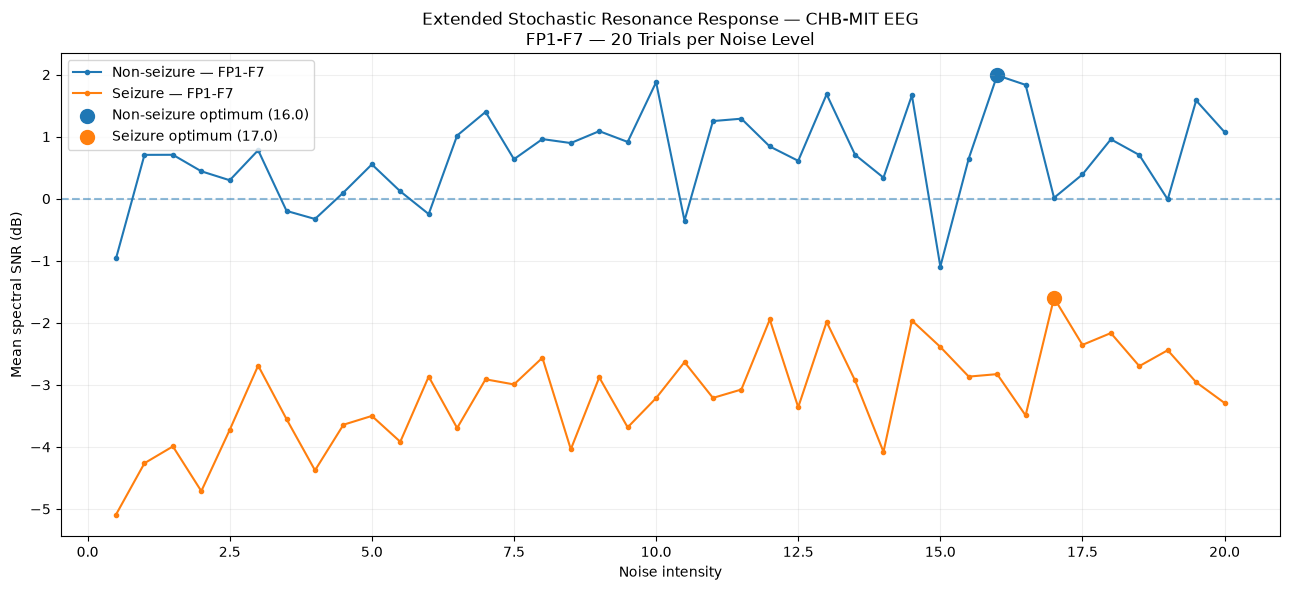

In [ ]:
# ==========================================
# SR — EXTENDED NOISE RANGE CHECK
# ==========================================

sr_extended_noise_levels = np.arange(
    0.5,
    20.01,
    0.5
)

sr_extended_trials = 20

extended_non_snr = []
extended_seiz_snr = []

extended_non_trans = []
extended_seiz_trans = []

extended_rng = np.random.default_rng(42)


for noise_level in sr_extended_noise_levels:

    non_snr_trials = []
    seiz_snr_trials = []

    non_trans_trials = []
    seiz_trans_trials = []

    for trial in range(sr_extended_trials):

        non_rng = np.random.default_rng(
            extended_rng.integers(0, 2**32 - 1)
        )

        seiz_rng = np.random.default_rng(
            extended_rng.integers(0, 2**32 - 1)
        )


        # ----------------------------------
        # NON-SEIZURE
        # ----------------------------------

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=non_rng
        )

        non_snr_trials.append(
            sr_spectral_snr(
                non_output,
                sr_sfreq,
                sr_non_freq
            )
        )

        non_trans_trials.append(
            count_sr_transitions(non_output)
        )


        # ----------------------------------
        # SEIZURE
        # ----------------------------------

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=seiz_rng
        )

        seiz_snr_trials.append(
            sr_spectral_snr(
                seiz_output,
                sr_sfreq,
                sr_seiz_freq
            )
        )

        seiz_trans_trials.append(
            count_sr_transitions(seiz_output)
        )


    extended_non_snr.append(
        np.nanmean(non_snr_trials)
    )

    extended_seiz_snr.append(
        np.nanmean(seiz_snr_trials)
    )

    extended_non_trans.append(
        np.mean(non_trans_trials)
    )

    extended_seiz_trans.append(
        np.mean(seiz_trans_trials)
    )


# Convert

extended_non_snr = np.array(extended_non_snr)
extended_seiz_snr = np.array(extended_seiz_snr)

extended_non_trans = np.array(extended_non_trans)
extended_seiz_trans = np.array(extended_seiz_trans)


# ------------------------------------------
# Optima
# ------------------------------------------

non_idx = np.nanargmax(extended_non_snr)
seiz_idx = np.nanargmax(extended_seiz_snr)


print("EXTENDED SR ANALYSIS")
print("====================")

print(
    f"Non-seizure optimum: "
    f"{sr_extended_noise_levels[non_idx]:.1f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{extended_non_snr[non_idx]:.3f} dB"
)

print(
    f"Non-seizure transitions: "
    f"{extended_non_trans[non_idx]:.1f}"
)

print()

print(
    f"Seizure optimum: "
    f"{sr_extended_noise_levels[seiz_idx]:.1f}"
)

print(
    f"Seizure maximum SNR: "
    f"{extended_seiz_snr[seiz_idx]:.3f} dB"
)

print(
    f"Seizure transitions: "
    f"{extended_seiz_trans[seiz_idx]:.1f}"
)


# ==========================================
# GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

plt.plot(
    sr_extended_noise_levels,
    extended_non_snr,
    marker="o",
    markersize=3,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    sr_extended_noise_levels,
    extended_seiz_snr,
    marker="o",
    markersize=3,
    label="Seizure — FP1-F7"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.scatter(
    sr_extended_noise_levels[non_idx],
    extended_non_snr[non_idx],
    s=100,
    label=f"Non-seizure optimum ({sr_extended_noise_levels[non_idx]:.1f})"
)

plt.scatter(
    sr_extended_noise_levels[seiz_idx],
    extended_seiz_snr[seiz_idx],
    s=100,
    label=f"Seizure optimum ({sr_extended_noise_levels[seiz_idx]:.1f})"
)

plt.xlabel("Noise intensity")
plt.ylabel("Mean spectral SNR (dB)")

plt.title(
    "Extended Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CR — Compression / Reconstruction Baseline
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# Established EEG windows
# ------------------------------------------

cr_nonseizure = windows[298][0]   # FP1-F7, 2980–2990 s
cr_seizure = windows[299][0]       # FP1-F7, 3000–3010 s

cr_sfreq = raw_filtered.info["sfreq"]

print("CR Input Signals")
print("================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Sampling frequency:", cr_sfreq, "Hz")

print()
print("Non-seizure:")
print("  Window: 2980–2990 s")
print("  Samples:", len(cr_nonseizure))

print()
print("Seizure:")
print("  Window: 3000–3010 s")
print("  Samples:", len(cr_seizure))


# ------------------------------------------
# Compression function
# ------------------------------------------

def compress_signal(signal, compression_factor):
    """
    Simple temporal downsampling compression.

    compression_factor = number of original
    samples represented by one compressed sample.
    """

    factor = int(compression_factor)

    compressed = signal[::factor]

    return compressed


# ------------------------------------------
# Reconstruction
# ------------------------------------------

def reconstruct_signal(
    compressed_signal,
    original_length,
    compression_factor
):
    """
    Reconstruct the compressed signal using
    linear interpolation.
    """

    factor = int(compression_factor)

    compressed_positions = (
        np.arange(len(compressed_signal))
        * factor
    )

    original_positions = np.arange(
        original_length
    )

    reconstructed = np.interp(
        original_positions,
        compressed_positions,
        compressed_signal
    )

    return reconstructed


# ------------------------------------------
# Test one compression level
# ------------------------------------------

cr_test_factor = 4

non_compressed = compress_signal(
    cr_nonseizure,
    cr_test_factor
)

seiz_compressed = compress_signal(
    cr_seizure,
    cr_test_factor
)

non_reconstructed = reconstruct_signal(
    non_compressed,
    len(cr_nonseizure),
    cr_test_factor
)

seiz_reconstructed = reconstruct_signal(
    seiz_compressed,
    len(cr_seizure),
    cr_test_factor
)


# ------------------------------------------
# Compression ratio
# ------------------------------------------

non_cr = (
    len(cr_nonseizure)
    /
    len(non_compressed)
)

seiz_cr = (
    len(cr_seizure)
    /
    len(seiz_compressed)
)


# ------------------------------------------
# Reconstruction metrics
# ------------------------------------------

def reconstruction_metrics(
    original,
    reconstructed
):

    mse = np.mean(
        (original - reconstructed) ** 2
    )

    rmse = np.sqrt(mse)

    correlation = np.corrcoef(
        original,
        reconstructed
    )[0, 1]

    return rmse, correlation


non_rmse, non_corr = reconstruction_metrics(
    cr_nonseizure,
    non_reconstructed
)

seiz_rmse, seiz_corr = reconstruction_metrics(
    cr_seizure,
    seiz_reconstructed
)


# ------------------------------------------
# Results
# ------------------------------------------

print()
print("CR Baseline Test")
print("================")

print()
print("Compression factor:", cr_test_factor)

print()
print("Non-seizure:")
print("  Original samples:", len(cr_nonseizure))
print("  Compressed samples:", len(non_compressed))
print(f"  Compression ratio: {non_cr:.2f}:1")
print(f"  Reconstruction RMSE: {non_rmse:.6e}")
print(f"  Reconstruction correlation: {non_corr:.4f}")

print()
print("Seizure:")
print("  Original samples:", len(cr_seizure))
print("  Compressed samples:", len(seiz_compressed))
print(f"  Compression ratio: {seiz_cr:.2f}:1")
print(f"  Reconstruction RMSE: {seiz_rmse:.6e}")
print(f"  Reconstruction correlation: {seiz_corr:.4f}")

CR Input Signals
File: chb01_03.edf
Channel: FP1-F7
Sampling frequency: 256.0 Hz

Non-seizure:
  Window: 2980–2990 s
  Samples: 2560

Seizure:
  Window: 3000–3010 s
  Samples: 2560

CR Baseline Test

Compression factor: 4

Non-seizure:
  Original samples: 2560
  Compressed samples: 640
  Compression ratio: 4.00:1
  Reconstruction RMSE: 3.555959e-06
  Reconstruction correlation: 0.9922

Seizure:
  Original samples: 2560
  Compressed samples: 640
  Compression ratio: 4.00:1
  Reconstruction RMSE: 1.996413e-05
  Reconstruction correlation: 0.9716


CR COMPRESSION SWEEP

Factor | Ratio | Non-seiz Corr | Seiz Corr | Non-seiz RMSE | Seiz RMSE
------------------------------------------------------------------------------
     2 |   2.0:1 |        0.9990 |    0.9961 |  1.259854e-06 | 7.504128e-06
     4 |   4.0:1 |        0.9922 |    0.9716 |  3.555959e-06 | 1.996413e-05
     8 |   8.0:1 |        0.9662 |    0.9432 |  7.649519e-06 | 2.817693e-05
    16 |  16.0:1 |        0.8400 |    0.9146 |  1.562537e-05 | 3.413741e-05
    32 |  32.0:1 |        0.7838 |    0.8105 |  1.754505e-05 | 4.948545e-05


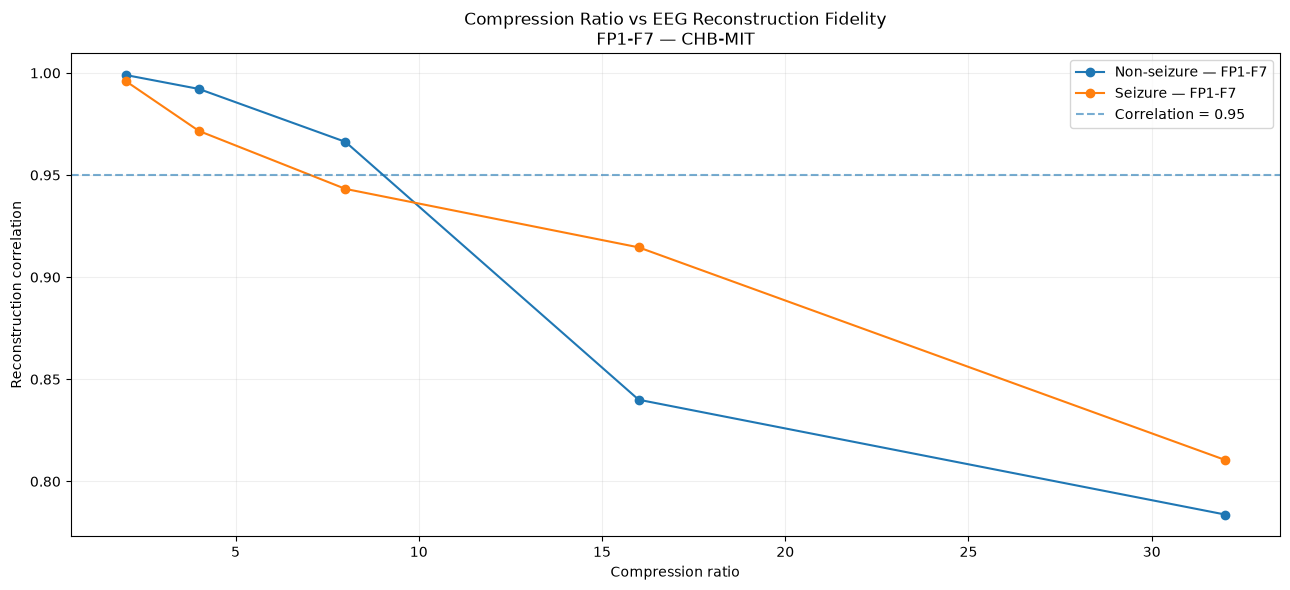

In [ ]:
# ==========================================
# CR — Compression Ratio vs Signal Fidelity
# ==========================================

# Compression factors to evaluate
cr_factors = [
    2,
    4,
    8,
    16,
    32
]

cr_non_ratios = []
cr_seiz_ratios = []

cr_non_rmse = []
cr_seiz_rmse = []

cr_non_corr = []
cr_seiz_corr = []


# ------------------------------------------
# Evaluate each compression factor
# ------------------------------------------

for factor in cr_factors:

    # Compress
    non_compressed = compress_signal(
        cr_nonseizure,
        factor
    )

    seiz_compressed = compress_signal(
        cr_seizure,
        factor
    )

    # Reconstruct
    non_reconstructed = reconstruct_signal(
        non_compressed,
        len(cr_nonseizure),
        factor
    )

    seiz_reconstructed = reconstruct_signal(
        seiz_compressed,
        len(cr_seizure),
        factor
    )

    # Compression ratios
    cr_non_ratios.append(
        len(cr_nonseizure)
        / len(non_compressed)
    )

    cr_seiz_ratios.append(
        len(cr_seizure)
        / len(seiz_compressed)
    )

    # Fidelity
    non_rmse, non_corr = reconstruction_metrics(
        cr_nonseizure,
        non_reconstructed
    )

    seiz_rmse, seiz_corr = reconstruction_metrics(
        cr_seizure,
        seiz_reconstructed
    )

    cr_non_rmse.append(non_rmse)
    cr_seiz_rmse.append(seiz_rmse)

    cr_non_corr.append(non_corr)
    cr_seiz_corr.append(seiz_corr)


# Convert to arrays

cr_non_ratios = np.array(cr_non_ratios)
cr_seiz_ratios = np.array(cr_seiz_ratios)

cr_non_rmse = np.array(cr_non_rmse)
cr_seiz_rmse = np.array(cr_seiz_rmse)

cr_non_corr = np.array(cr_non_corr)
cr_seiz_corr = np.array(cr_seiz_corr)


# ==========================================
# PRINT RESULTS
# ==========================================

print("CR COMPRESSION SWEEP")
print("====================")

print()
print(
    "Factor | Ratio | Non-seiz Corr | "
    "Seiz Corr | Non-seiz RMSE | Seiz RMSE"
)
print("-" * 78)

for i, factor in enumerate(cr_factors):

    print(
        f"{factor:6d} | "
        f"{cr_non_ratios[i]:5.1f}:1 | "
        f"{cr_non_corr[i]:13.4f} | "
        f"{cr_seiz_corr[i]:9.4f} | "
        f"{cr_non_rmse[i]:13.6e} | "
        f"{cr_seiz_rmse[i]:9.6e}"
    )


# ==========================================
# FINAL CR FIDELITY GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

plt.plot(
    cr_non_ratios,
    cr_non_corr,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_seiz_ratios,
    cr_seiz_corr,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.axhline(
    0.95,
    linestyle="--",
    alpha=0.6,
    label="Correlation = 0.95"
)

plt.xlabel("Compression ratio")
plt.ylabel("Reconstruction correlation")

plt.title(
    "Compression Ratio vs EEG Reconstruction Fidelity"
    "\nFP1-F7 — CHB-MIT"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [73]:
# ==========================================
# CR — Input Signals
# CHB-MIT chb01_03.edf — FP1-F7
# ==========================================

import mne
import numpy as np

cr_file = "../data/CHB-MIT/chb01/chb01_03.edf"
cr_channel = "FP1-F7"

cr_non_start = 2980
cr_non_end = 2990

cr_seiz_start = 3000
cr_seiz_end = 3010

# Load EDF
cr_raw = mne.io.read_raw_edf(
    cr_file,
    preload=True,
    verbose=False
)

# Select FP1-F7
cr_signal = cr_raw.get_data(
    picks=[cr_channel]
).flatten()

cr_sfreq = cr_raw.info["sfreq"]

# Convert time windows to samples
cr_non_start_sample = int(
    cr_non_start * cr_sfreq
)

cr_non_end_sample = int(
    cr_non_end * cr_sfreq
)

cr_seiz_start_sample = int(
    cr_seiz_start * cr_sfreq
)

cr_seiz_end_sample = int(
    cr_seiz_end * cr_sfreq
)

# Extract windows
cr_nonseizure = cr_signal[
    cr_non_start_sample:cr_non_end_sample
]

cr_seizure = cr_signal[
    cr_seiz_start_sample:cr_seiz_end_sample
]

print("CR Input Signals")
print("================")
print(f"File: {cr_file}")
print(f"Channel: {cr_channel}")
print(f"Sampling frequency: {cr_sfreq} Hz")
print()

print("Non-seizure:")
print(f"  Window: {cr_non_start}–{cr_non_end} s")
print(f"  Samples: {len(cr_nonseizure)}")

print()

print("Seizure:")
print(f"  Window: {cr_seiz_start}–{cr_seiz_end} s")
print(f"  Samples: {len(cr_seizure)}")

CR Input Signals
File: ../data/CHB-MIT/chb01/chb01_03.edf
Channel: FP1-F7
Sampling frequency: 256.0 Hz

Non-seizure:
  Window: 2980–2990 s
  Samples: 2560

Seizure:
  Window: 3000–3010 s
  Samples: 2560


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_32996\1531569502.py:19: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  cr_raw = mne.io.read_raw_edf(


In [74]:
# ============================================================
# CR — REAL CHB-MIT EEG INPUT
# ============================================================

from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Locate the real CHB-MIT recording
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

CR_EDF_PATH = (
    PROJECT_ROOT
    / "data"
    / "CHB-MIT"
    / "chb01"
    / "chb01_03.edf"
)

print("CR EDF path:")
print(CR_EDF_PATH)

print("File exists:", CR_EDF_PATH.exists())

if not CR_EDF_PATH.exists():
    raise FileNotFoundError(
        f"CHB-MIT EDF not found:\n{CR_EDF_PATH}"
    )

# ------------------------------------------------------------
# Load real EEG
# ------------------------------------------------------------

cr_raw = mne.io.read_raw_edf(
    CR_EDF_PATH,
    preload=True,
    verbose=False
)

cr_sfreq = cr_raw.info["sfreq"]

print("\nCR INPUT SIGNALS")
print("================")

print("File:", CR_EDF_PATH.name)
print("Sampling frequency:", cr_sfreq, "Hz")

# ------------------------------------------------------------
# Target channel
# ------------------------------------------------------------

CR_CHANNEL = "FP1-F7"

if CR_CHANNEL not in cr_raw.ch_names:
    raise ValueError(
        f"{CR_CHANNEL} not found in EDF."
    )

# ------------------------------------------------------------
# Real CHB-MIT windows
# ------------------------------------------------------------

CR_NORMAL_START = 2980
CR_NORMAL_END = 2990

CR_SEIZURE_START = 3000
CR_SEIZURE_END = 3010

normal_start_sample = int(
    CR_NORMAL_START * cr_sfreq
)

normal_end_sample = int(
    CR_NORMAL_END * cr_sfreq
)

seizure_start_sample = int(
    CR_SEIZURE_START * cr_sfreq
)

seizure_end_sample = int(
    CR_SEIZURE_END * cr_sfreq
)

# ------------------------------------------------------------
# Extract REAL EEG
# ------------------------------------------------------------

cr_nonseizure = cr_raw.get_data(
    picks=[CR_CHANNEL],
    start=normal_start_sample,
    stop=normal_end_sample
)[0]

cr_seizure = cr_raw.get_data(
    picks=[CR_CHANNEL],
    start=seizure_start_sample,
    stop=seizure_end_sample
)[0]

# ------------------------------------------------------------
# Time axes
# ------------------------------------------------------------

cr_normal_time = np.arange(
    len(cr_nonseizure)
) / cr_sfreq

cr_seizure_time = np.arange(
    len(cr_seizure)
) / cr_sfreq

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

expected_samples = int(
    10 * cr_sfreq
)

assert len(cr_nonseizure) == expected_samples
assert len(cr_seizure) == expected_samples

print("Channel:", CR_CHANNEL)

print("\nNon-seizure:")
print(
    f"  Window: "
    f"{CR_NORMAL_START}–{CR_NORMAL_END} s"
)
print(
    "  Samples:",
    len(cr_nonseizure)
)

print("\nSeizure:")
print(
    f"  Window: "
    f"{CR_SEIZURE_START}–{CR_SEIZURE_END} s"
)
print(
    "  Samples:",
    len(cr_seizure)
)

CR EDF path:
c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
File exists: True


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_32996\4193759396.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  cr_raw = mne.io.read_raw_edf(



CR INPUT SIGNALS
File: chb01_03.edf
Sampling frequency: 256.0 Hz
Channel: FP1-F7

Non-seizure:
  Window: 2980–2990 s
  Samples: 2560

Seizure:
  Window: 3000–3010 s
  Samples: 2560


In [75]:
# ============================================================
# CR — COMPRESSION / RECONSTRUCTION FUNCTIONS
# ============================================================

def compress_signal(signal, factor):
    """
    Downsample the real EEG by retaining every
    'factor'-th sample.
    """

    if factor < 2:
        raise ValueError(
            "Compression factor must be >= 2."
        )

    compressed = signal[::factor]

    return compressed


def reconstruct_signal(
    compressed_signal,
    original_length,
    factor
):
    """
    Reconstruct the EEG onto the original
    sample grid using linear interpolation.
    """

    compressed_indices = (
        np.arange(len(compressed_signal))
        * factor
    )

    original_indices = np.arange(
        original_length
    )

    # Ensure interpolation reaches the final
    # original sample when necessary.
    if compressed_indices[-1] < original_length - 1:

        compressed_indices = np.append(
            compressed_indices,
            original_length - 1
        )

        compressed_signal = np.append(
            compressed_signal,
            compressed_signal[-1]
        )

    reconstructed = np.interp(
        original_indices,
        compressed_indices,
        compressed_signal
    )

    return reconstructed


def reconstruction_metrics(
    original,
    reconstructed
):
    """
    Calculate reconstruction fidelity.
    """

    error = (
        original - reconstructed
    )

    mse = np.mean(
        error ** 2
    )

    rmse = np.sqrt(mse)

    correlation = np.corrcoef(
        original,
        reconstructed
    )[0, 1]

    return rmse, correlation


print("CR helper functions loaded.")
print("----------------------------")
print("compress_signal        ✓")
print("reconstruct_signal     ✓")
print("reconstruction_metrics ✓")

CR helper functions loaded.
----------------------------
compress_signal        ✓
reconstruct_signal     ✓
reconstruction_metrics ✓


In [76]:
# ============================================================
# CR — ACTUAL CHB-MIT COMPRESSION SWEEP
# ============================================================

cr_factors = [
    2,
    4,
    8,
    16,
    32
]

cr_results = []

for factor in cr_factors:

    # --------------------------------------------------------
    # NON-SEIZURE
    # --------------------------------------------------------

    non_compressed = compress_signal(
        cr_nonseizure,
        factor
    )

    non_reconstructed = reconstruct_signal(
        non_compressed,
        len(cr_nonseizure),
        factor
    )

    non_rmse, non_corr = reconstruction_metrics(
        cr_nonseizure,
        non_reconstructed
    )

    non_ratio = (
        len(cr_nonseizure)
        / len(non_compressed)
    )

    # --------------------------------------------------------
    # SEIZURE
    # --------------------------------------------------------

    seiz_compressed = compress_signal(
        cr_seizure,
        factor
    )

    seiz_reconstructed = reconstruct_signal(
        seiz_compressed,
        len(cr_seizure),
        factor
    )

    seiz_rmse, seiz_corr = reconstruction_metrics(
        cr_seizure,
        seiz_reconstructed
    )

    seiz_ratio = (
        len(cr_seizure)
        / len(seiz_compressed)
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    cr_results.append({
        "factor": factor,

        "non_ratio": non_ratio,
        "non_rmse": non_rmse,
        "non_corr": non_corr,

        "seiz_ratio": seiz_ratio,
        "seiz_rmse": seiz_rmse,
        "seiz_corr": seiz_corr
    })


# ============================================================
# PRINT ACTUAL RESULTS
# ============================================================

print("CR — ACTUAL CHB-MIT RESULTS")
print("============================")

print(
    "Factor | Ratio | Non-seiz Corr | "
    "Seiz Corr | Non-seiz RMSE | Seiz RMSE"
)

print("-" * 78)

for result in cr_results:

    print(
        f"{result['factor']:6d} | "
        f"{result['non_ratio']:5.1f}:1 | "
        f"{result['non_corr']:13.4f} | "
        f"{result['seiz_corr']:9.4f} | "
        f"{result['non_rmse']:13.6e} | "
        f"{result['seiz_rmse']:9.6e}"
    )

CR — ACTUAL CHB-MIT RESULTS
Factor | Ratio | Non-seiz Corr | Seiz Corr | Non-seiz RMSE | Seiz RMSE
------------------------------------------------------------------------------
     2 |   2.0:1 |        0.9986 |    0.9843 |  1.522990e-06 | 1.513300e-05
     4 |   4.0:1 |        0.9917 |    0.9601 |  3.703181e-06 | 2.397125e-05
     8 |   8.0:1 |        0.9662 |    0.9315 |  7.694438e-06 | 3.124984e-05
    16 |  16.0:1 |        0.8429 |    0.9067 |  1.570029e-05 | 3.609951e-05
    32 |  32.0:1 |        0.7885 |    0.8073 |  1.757880e-05 | 5.068958e-05


FINAL CR FIDELITY ANALYSIS
Fidelity threshold: 0.95
Selected compression factor: 4:1
Non-seizure correlation: 0.9917
Seizure correlation: 0.9601
Non-seizure RMSE: 3.703181e-06
Seizure RMSE: 2.397125e-05


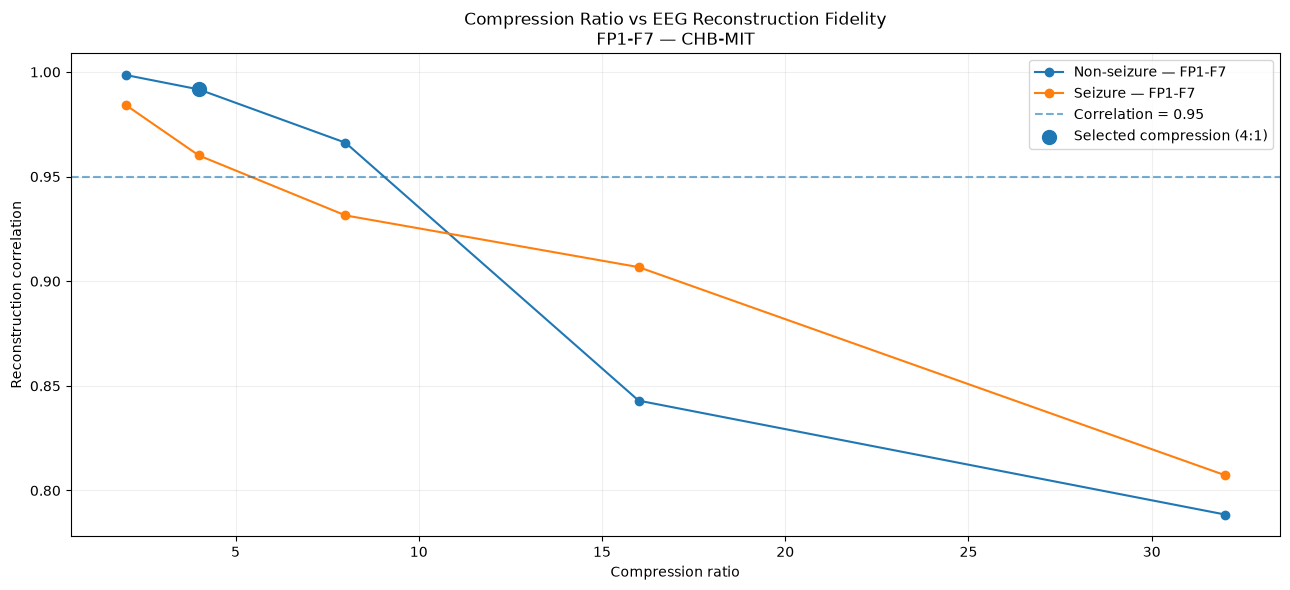

In [77]:
# ============================================================
# CR — FINAL FIDELITY ANALYSIS
# ============================================================

# Extract results for plotting

cr_plot_ratios = np.array([
    result["non_ratio"]
    for result in cr_results
])

cr_plot_non_corr = np.array([
    result["non_corr"]
    for result in cr_results
])

cr_plot_seiz_corr = np.array([
    result["seiz_corr"]
    for result in cr_results
])


# ------------------------------------------------------------
# Determine maximum compression satisfying fidelity criterion
# ------------------------------------------------------------

CR_FIDELITY_THRESHOLD = 0.95

valid_factors = []

for result in cr_results:

    if (
        result["non_corr"] >= CR_FIDELITY_THRESHOLD
        and
        result["seiz_corr"] >= CR_FIDELITY_THRESHOLD
    ):
        valid_factors.append(
            result["factor"]
        )


if len(valid_factors) == 0:

    raise ValueError(
        "No compression factor satisfies "
        "the 0.95 correlation criterion."
    )


cr_selected_factor = max(valid_factors)


# ------------------------------------------------------------
# Find selected result
# ------------------------------------------------------------

cr_selected_result = next(
    result
    for result in cr_results
    if result["factor"] == cr_selected_factor
)


# ============================================================
# PRINT FINAL CR DECISION
# ============================================================

print("FINAL CR FIDELITY ANALYSIS")
print("==========================")

print(
    f"Fidelity threshold: "
    f"{CR_FIDELITY_THRESHOLD:.2f}"
)

print(
    f"Selected compression factor: "
    f"{cr_selected_factor}:1"
)

print(
    f"Non-seizure correlation: "
    f"{cr_selected_result['non_corr']:.4f}"
)

print(
    f"Seizure correlation: "
    f"{cr_selected_result['seiz_corr']:.4f}"
)

print(
    f"Non-seizure RMSE: "
    f"{cr_selected_result['non_rmse']:.6e}"
)

print(
    f"Seizure RMSE: "
    f"{cr_selected_result['seiz_rmse']:.6e}"
)


# ============================================================
# FINAL CR GRAPH
# ============================================================

plt.figure(figsize=(13, 6))

plt.plot(
    cr_plot_ratios,
    cr_plot_non_corr,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_plot_ratios,
    cr_plot_seiz_corr,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.axhline(
    CR_FIDELITY_THRESHOLD,
    linestyle="--",
    alpha=0.6,
    label="Correlation = 0.95"
)

# Highlight selected compression point

plt.scatter(
    cr_selected_result["non_ratio"],
    cr_selected_result["non_corr"],
    s=100,
    zorder=5,
    label=f"Selected compression ({cr_selected_factor}:1)"
)

plt.xlabel("Compression ratio")
plt.ylabel("Reconstruction correlation")

plt.title(
    "Compression Ratio vs EEG Reconstruction Fidelity"
    "\nFP1-F7 — CHB-MIT"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

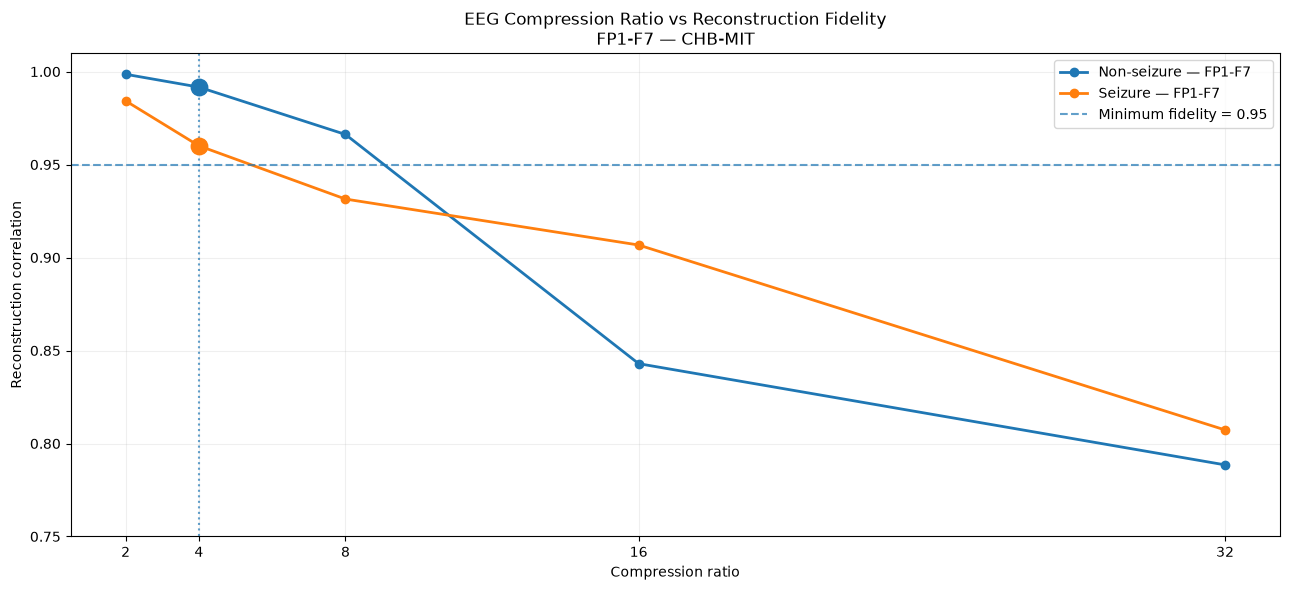

In [78]:
# ============================================================
# CR — FINAL PRESENTATION GRAPH
# ============================================================

plt.figure(figsize=(13, 6))

# ------------------------------------------------------------
# Fidelity curves
# ------------------------------------------------------------

plt.plot(
    cr_plot_ratios,
    cr_plot_non_corr,
    marker="o",
    linewidth=2,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_plot_ratios,
    cr_plot_seiz_corr,
    marker="o",
    linewidth=2,
    label="Seizure — FP1-F7"
)

# ------------------------------------------------------------
# Fidelity threshold
# ------------------------------------------------------------

plt.axhline(
    CR_FIDELITY_THRESHOLD,
    linestyle="--",
    alpha=0.7,
    label="Minimum fidelity = 0.95"
)

# ------------------------------------------------------------
# Highlight selected 4:1 compression
# ------------------------------------------------------------

plt.scatter(
    cr_selected_result["non_ratio"],
    cr_selected_result["non_corr"],
    s=140,
    zorder=5
)

plt.scatter(
    cr_selected_result["seiz_ratio"],
    cr_selected_result["seiz_corr"],
    s=140,
    zorder=5
)

# Vertical reference at selected compression

plt.axvline(
    cr_selected_factor,
    linestyle=":",
    alpha=0.7
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(
    "Compression ratio"
)

plt.ylabel(
    "Reconstruction correlation"
)

plt.title(
    "EEG Compression Ratio vs Reconstruction Fidelity"
    "\nFP1-F7 — CHB-MIT"
)

plt.xticks(
    cr_plot_ratios
)

plt.ylim(
    0.75,
    1.01
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()

FINAL CR RECONSTRUCTION
Compression ratio: 4:1

Non-seizure:
  Original samples: 2560
  Compressed samples: 640
  Reconstruction correlation: 0.9917
  Reconstruction RMSE: 3.703181e-06

Seizure:
  Original samples: 2560
  Compressed samples: 640
  Reconstruction correlation: 0.9601
  Reconstruction RMSE: 2.397125e-05


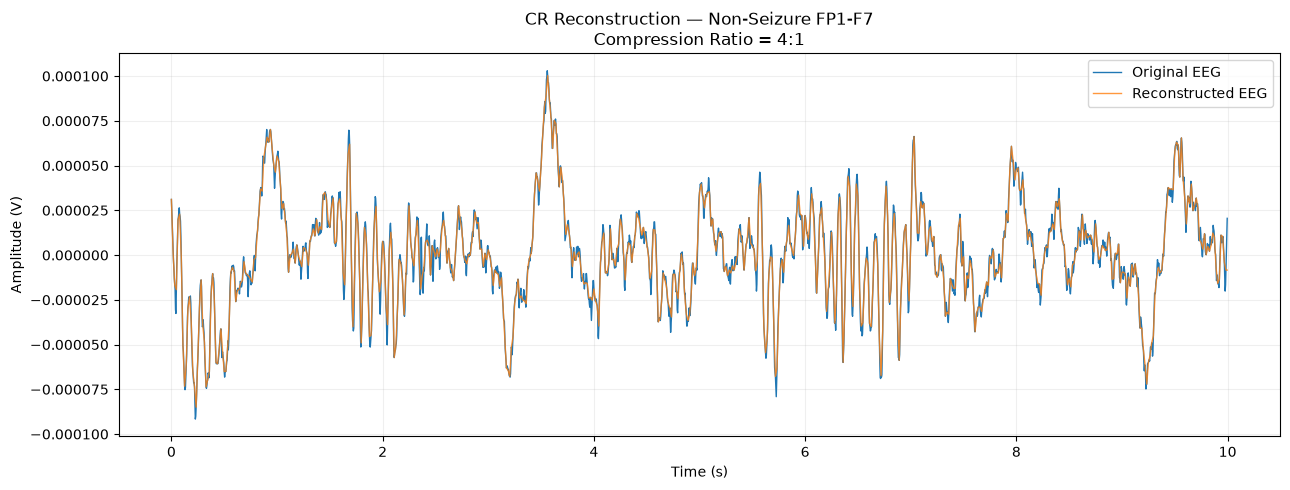

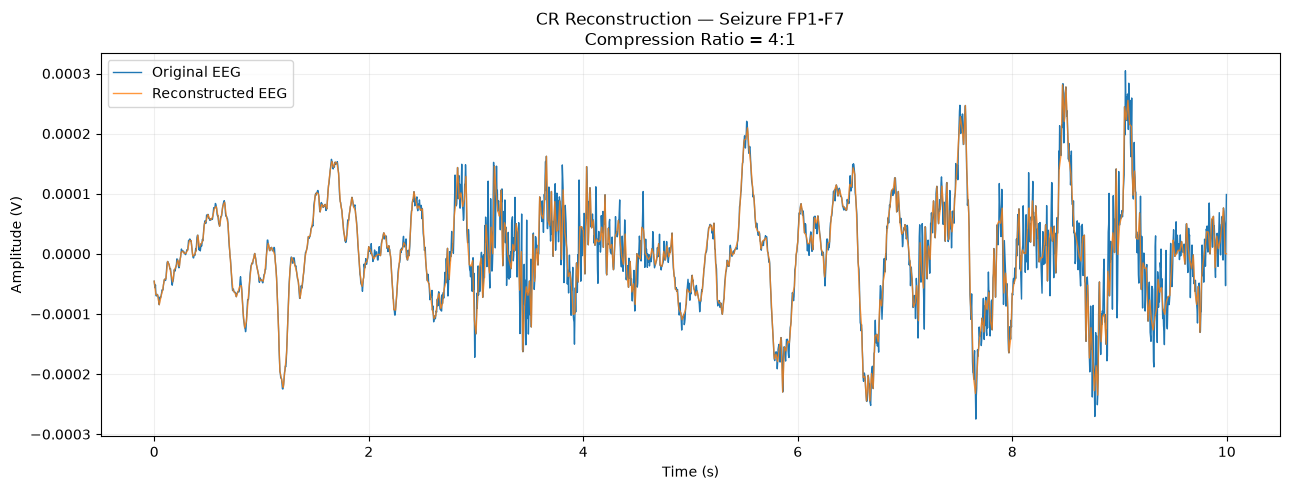

In [79]:
# ============================================================
# CR — FINAL 4:1 RECONSTRUCTION VISUALIZATION
# ============================================================

# Use the selected compression factor determined above
cr_final_factor = cr_selected_factor

# ------------------------------------------------------------
# Compress and reconstruct REAL EEG
# ------------------------------------------------------------

cr_final_non_compressed = compress_signal(
    cr_nonseizure,
    cr_final_factor
)

cr_final_non_reconstructed = reconstruct_signal(
    cr_final_non_compressed,
    len(cr_nonseizure),
    cr_final_factor
)

cr_final_seiz_compressed = compress_signal(
    cr_seizure,
    cr_final_factor
)

cr_final_seiz_reconstructed = reconstruct_signal(
    cr_final_seiz_compressed,
    len(cr_seizure),
    cr_final_factor
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

cr_final_non_rmse, cr_final_non_corr = reconstruction_metrics(
    cr_nonseizure,
    cr_final_non_reconstructed
)

cr_final_seiz_rmse, cr_final_seiz_corr = reconstruction_metrics(
    cr_seizure,
    cr_final_seiz_reconstructed
)

print("FINAL CR RECONSTRUCTION")
print("=======================")

print(
    f"Compression ratio: "
    f"{cr_final_factor}:1"
)

print()

print("Non-seizure:")
print(
    f"  Original samples: "
    f"{len(cr_nonseizure)}"
)
print(
    f"  Compressed samples: "
    f"{len(cr_final_non_compressed)}"
)
print(
    f"  Reconstruction correlation: "
    f"{cr_final_non_corr:.4f}"
)
print(
    f"  Reconstruction RMSE: "
    f"{cr_final_non_rmse:.6e}"
)

print()

print("Seizure:")
print(
    f"  Original samples: "
    f"{len(cr_seizure)}"
)
print(
    f"  Compressed samples: "
    f"{len(cr_final_seiz_compressed)}"
)
print(
    f"  Reconstruction correlation: "
    f"{cr_final_seiz_corr:.4f}"
)
print(
    f"  Reconstruction RMSE: "
    f"{cr_final_seiz_rmse:.6e}"
)


# ============================================================
# NON-SEIZURE — ORIGINAL VS RECONSTRUCTED
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    cr_normal_time,
    cr_nonseizure,
    linewidth=1,
    label="Original EEG"
)

plt.plot(
    cr_normal_time,
    cr_final_non_reconstructed,
    linewidth=1,
    alpha=0.8,
    label="Reconstructed EEG"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")

plt.title(
    f"CR Reconstruction — Non-Seizure FP1-F7"
    f"\nCompression Ratio = {cr_final_factor}:1"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# SEIZURE — ORIGINAL VS RECONSTRUCTED
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    cr_seizure_time,
    cr_seizure,
    linewidth=1,
    label="Original EEG"
)

plt.plot(
    cr_seizure_time,
    cr_final_seiz_reconstructed,
    linewidth=1,
    alpha=0.8,
    label="Reconstructed EEG"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")

plt.title(
    f"CR Reconstruction — Seizure FP1-F7"
    f"\nCompression Ratio = {cr_final_factor}:1"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

FINAL CR SPECTRAL PRESERVATION
Compression ratio: 4:1

NON-SEIZURE
-----------
Original dominant frequency: 1.25 Hz
Reconstructed dominant frequency: 1.25 Hz
Dominant frequency shift: 0.00 Hz
Spectral correlation: 0.9961

SEIZURE
-------
Original dominant frequency: 1.25 Hz
Reconstructed dominant frequency: 1.25 Hz
Dominant frequency shift: 0.00 Hz
Spectral correlation: 0.9999


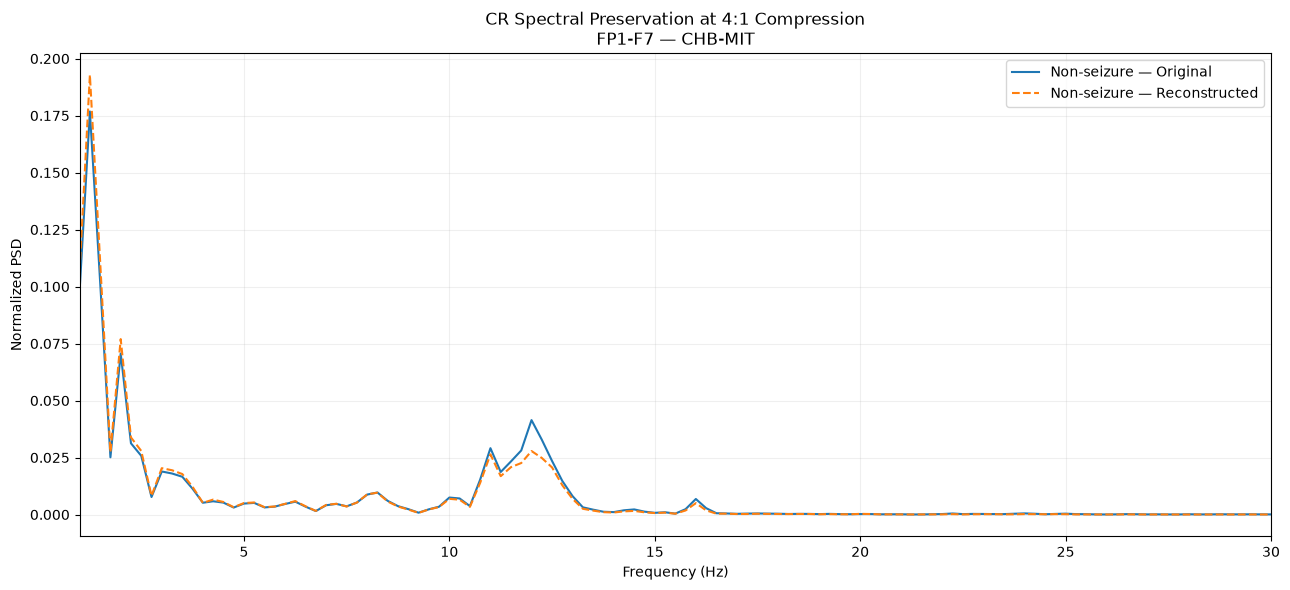

In [80]:
# ==========================================
# CR — FINAL SPECTRAL PRESERVATION VALIDATION
# Selected compression: 4:1
# ==========================================

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------
# Selected compression
# ------------------------------------------

cr_validation_factor = 4


# ------------------------------------------
# Compress and reconstruct actual CHB-MIT EEG
# ------------------------------------------

cr_val_non_compressed = compress_signal(
    cr_nonseizure,
    cr_validation_factor
)

cr_val_seiz_compressed = compress_signal(
    cr_seizure,
    cr_validation_factor
)

cr_val_non_reconstructed = reconstruct_signal(
    cr_val_non_compressed,
    len(cr_nonseizure),
    cr_validation_factor
)

cr_val_seiz_reconstructed = reconstruct_signal(
    cr_val_seiz_compressed,
    len(cr_seizure),
    cr_validation_factor
)


# ==========================================
# Spectral comparison function
# ==========================================

def spectral_preservation(
    original,
    reconstructed,
    sfreq
):

    frequencies, original_power = welch(
        original,
        fs=sfreq,
        nperseg=min(1024, len(original))
    )

    _, reconstructed_power = welch(
        reconstructed,
        fs=sfreq,
        nperseg=min(1024, len(reconstructed))
    )

    # Focus on relevant EEG range
    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    original_power = original_power[mask]
    reconstructed_power = reconstructed_power[mask]

    # Normalize PSD shapes for comparison
    original_norm = (
        original_power /
        np.sum(original_power)
    )

    reconstructed_norm = (
        reconstructed_power /
        np.sum(reconstructed_power)
    )

    # Correlation between original and reconstructed spectra
    spectral_corr = np.corrcoef(
        original_norm,
        reconstructed_norm
    )[0, 1]

    # Dominant frequencies
    original_peak = frequencies[
        np.argmax(original_power)
    ]

    reconstructed_peak = frequencies[
        np.argmax(reconstructed_power)
    ]

    peak_shift = abs(
        original_peak -
        reconstructed_peak
    )

    return (
        frequencies,
        original_norm,
        reconstructed_norm,
        spectral_corr,
        original_peak,
        reconstructed_peak,
        peak_shift
    )


# ==========================================
# Non-seizure spectral preservation
# ==========================================

(
    cr_freq_non,
    cr_psd_non_original,
    cr_psd_non_reconstructed,
    cr_spec_corr_non,
    cr_peak_non_original,
    cr_peak_non_reconstructed,
    cr_peak_shift_non
) = spectral_preservation(
    cr_nonseizure,
    cr_val_non_reconstructed,
    cr_sfreq
)


# ==========================================
# Seizure spectral preservation
# ==========================================

(
    cr_freq_seiz,
    cr_psd_seiz_original,
    cr_psd_seiz_reconstructed,
    cr_spec_corr_seiz,
    cr_peak_seiz_original,
    cr_peak_seiz_reconstructed,
    cr_peak_shift_seiz
) = spectral_preservation(
    cr_seizure,
    cr_val_seiz_reconstructed,
    cr_sfreq
)


# ==========================================
# PRINT FINAL VALIDATION
# ==========================================

print("FINAL CR SPECTRAL PRESERVATION")
print("==============================")

print(
    f"Compression ratio: "
    f"{cr_validation_factor}:1"
)

print()

print("NON-SEIZURE")
print("-----------")

print(
    f"Original dominant frequency: "
    f"{cr_peak_non_original:.2f} Hz"
)

print(
    f"Reconstructed dominant frequency: "
    f"{cr_peak_non_reconstructed:.2f} Hz"
)

print(
    f"Dominant frequency shift: "
    f"{cr_peak_shift_non:.2f} Hz"
)

print(
    f"Spectral correlation: "
    f"{cr_spec_corr_non:.4f}"
)

print()

print("SEIZURE")
print("-------")

print(
    f"Original dominant frequency: "
    f"{cr_peak_seiz_original:.2f} Hz"
)

print(
    f"Reconstructed dominant frequency: "
    f"{cr_peak_seiz_reconstructed:.2f} Hz"
)

print(
    f"Dominant frequency shift: "
    f"{cr_peak_shift_seiz:.2f} Hz"
)

print(
    f"Spectral correlation: "
    f"{cr_spec_corr_seiz:.4f}"
)


# ==========================================
# FINAL SPECTRAL PRESERVATION GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

plt.plot(
    cr_freq_non,
    cr_psd_non_original,
    label="Non-seizure — Original"
)

plt.plot(
    cr_freq_non,
    cr_psd_non_reconstructed,
    linestyle="--",
    label="Non-seizure — Reconstructed"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized PSD")

plt.title(
    "CR Spectral Preservation at 4:1 Compression"
    "\nFP1-F7 — CHB-MIT"
)

plt.xlim(1, 30)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CR — FINAL SPECTRAL PRESERVATION VALIDATION
# Selected compression: 4:1
# Actual CHB-MIT EEG
# ==========================================

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------
# Selected compression
# ------------------------------------------

cr_validation_factor = 4


# ------------------------------------------
# Compress and reconstruct
# ------------------------------------------

cr_val_non_compressed = compress_signal(
    cr_nonseizure,
    cr_validation_factor
)

cr_val_seiz_compressed = compress_signal(
    cr_seizure,
    cr_validation_factor
)

cr_val_non_reconstructed = reconstruct_signal(
    cr_val_non_compressed,
    len(cr_nonseizure),
    cr_validation_factor
)

cr_val_seiz_reconstructed = reconstruct_signal(
    cr_val_seiz_compressed,
    len(cr_seizure),
    cr_validation_factor
)


# ==========================================
# Spectral preservation
# Same Welch setup as characteristic
# frequency analysis
# ==========================================

def final_spectral_comparison(
    original,
    reconstructed,
    sfreq
):

    frequencies, original_power = welch(
        original,
        fs=sfreq,
        nperseg=len(original)
    )

    _, reconstructed_power = welch(
        reconstructed,
        fs=sfreq,
        nperseg=len(reconstructed)
    )

    # 1–30 Hz EEG range
    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    original_power = original_power[mask]
    reconstructed_power = reconstructed_power[mask]

    # Normalize PSD for shape comparison
    original_norm = (
        original_power /
        np.sum(original_power)
    )

    reconstructed_norm = (
        reconstructed_power /
        np.sum(reconstructed_power)
    )

    spectral_corr = np.corrcoef(
        original_norm,
        reconstructed_norm
    )[0, 1]

    original_peak = frequencies[
        np.argmax(original_power)
    ]

    reconstructed_peak = frequencies[
        np.argmax(reconstructed_power)
    ]

    peak_shift = abs(
        original_peak -
        reconstructed_peak
    )

    return (
        frequencies,
        original_norm,
        reconstructed_norm,
        spectral_corr,
        original_peak,
        reconstructed_peak,
        peak_shift
    )


# ==========================================
# NON-SEIZURE
# ==========================================

(
    cr_freq_non,
    cr_psd_non_original,
    cr_psd_non_reconstructed,
    cr_spec_corr_non,
    cr_peak_non_original,
    cr_peak_non_reconstructed,
    cr_peak_shift_non
) = final_spectral_comparison(
    cr_nonseizure,
    cr_val_non_reconstructed,
    cr_sfreq
)


# ==========================================
# SEIZURE
# ==========================================

(
    cr_freq_seiz,
    cr_psd_seiz_original,
    cr_psd_seiz_reconstructed,
    cr_spec_corr_seiz,
    cr_peak_seiz_original,
    cr_peak_seiz_reconstructed,
    cr_peak_shift_seiz
) = final_spectral_comparison(
    cr_seizure,
    cr_val_seiz_reconstructed,
    cr_sfreq
)


# ==========================================
# RESULTS
# ==========================================

print("FINAL CR SPECTRAL PRESERVATION")
print("==============================")

print(
    f"Compression ratio: "
    f"{cr_validation_factor}:1"
)

print()

print("NON-SEIZURE")
print("-----------")

print(
    f"Original dominant frequency: "
    f"{cr_peak_non_original:.2f} Hz"
)

print(
    f"Reconstructed dominant frequency: "
    f"{cr_peak_non_reconstructed:.2f} Hz"
)

print(
    f"Dominant frequency shift: "
    f"{cr_peak_shift_non:.2f} Hz"
)

print(
    f"Spectral correlation: "
    f"{cr_spec_corr_non:.4f}"
)

print()

print("SEIZURE")
print("-------")

print(
    f"Original dominant frequency: "
    f"{cr_peak_seiz_original:.2f} Hz"
)

print(
    f"Reconstructed dominant frequency: "
    f"{cr_peak_seiz_reconstructed:.2f} Hz"
)

print(
    f"Dominant frequency shift: "
    f"{cr_peak_shift_seiz:.2f} Hz"
)

print(
    f"Spectral correlation: "
    f"{cr_spec_corr_seiz:.4f}"
)


# ==========================================
# FINAL CR SPECTRAL GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

# Non-seizure
plt.plot(
    cr_freq_non,
    cr_psd_non_original,
    label="Non-seizure — Original"
)

plt.plot(
    cr_freq_non,
    cr_psd_non_reconstructed,
    linestyle="--",
    label="Non-seizure — Reconstructed"
)

# Seizure
plt.plot(
    cr_freq_seiz,
    cr_psd_seiz_original,
    label="Seizure — Original"
)

plt.plot(
    cr_freq_seiz,
    cr_psd_seiz_reconstructed,
    linestyle="--",
    label="Seizure — Reconstructed"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized PSD")

plt.title(
    "EEG Spectral Preservation at 4:1 Compression"
    "\nFP1-F7 — CHB-MIT"
)

plt.xlim(1, 30)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()